# Mini-PVA Totalp – Full Analysis (Week 1 + 2/3 + 4/5)

**Course:** Ecological and Energy Engineering – Project Work  
**Authors:** Chantal Fuchs, Lejla Beganovic, Nicola Noger  
**Site:** Totalp, Davos — N46.838°, E9.813°, 2486 m a.s.l.  
**Group focus:** Very steep ground inclinations (HN ≥ 20°)

---

This analysis uses data from the **Totalp Mini-PVA experiment**, a motorised miniature PV array located at 2486 m a.s.l. near Davos, Switzerland. The system automatically cycles through combinations of row spacing, module tilt, and ground slope, allowing a systematic parameter sweep that would be impossible at full scale. Our goal is to determine how these three configuration parameters affect PV yield over the winter period October 2024 – March 2025, with a specific focus on very steep ground inclinations (HN ≥ 20°). The final result is a performance map showing total bifacial yield as a function of all three parameters.

The full project analysis in three parts:

| Part | Weeks | Period | Focus |
|------|-------|--------|-------|
| **Part 1 – Single Day** | Week 1 | October 1, 2024 | Data loading, cleaning, normalisation, first visualisations |
| **Part 2 – Multi-Day** | Week 2/3 | Oct 2024 – Mar 2025 | Timezone handling, yield calculation, solar position, GHI variability |
| **Part 3 – Performance Map** | Week 4/5 | Oct 2024 – Mar 2025 | Bifacial yield, performance maps, POA irradiance, regression model |

## 0. Imports and Site Constants

All libraries and constants are defined once here and reused throughout both parts.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import glob
import os
import itertools
import warnings
import pvlib
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold

warnings.filterwarnings('ignore')  # suppress deprecation warnings (e.g. np.trapz)

---
# Part 1: Single Day Analysis (Week 1)

We start with a single day (October 1, 2024) to get familiar with the data structure, apply basic cleaning, and produce first visualisations.

## 1. Data Loading (Single Day)

We load four CSV files for October 1, 2024:

| File | Content | Resolution |
|------|---------|------------|
| `environmentaldata_singleday.csv` | GHI, DNI, zenith angle, air temperature | 10 s |
| `largeinstallation_measurementdata_singleday.csv` | Corrected and normalised power for module groups A–F | 10 s |
| `minipva_measurementdata_singleday.csv` | Mini-PVA measurements (Pmpp, U0, Ik, FF, configuration) | ~1 min |
| `STC_Powers.csv` | STC reference power per Mini-PVA channel | static |

All files use semicolon as separator and comma as decimal (European format): `sep=';'`, `decimal=','`.

We use `.info()` to check column names, data types and missing values.

In [2]:
# Environmental sensor data: GHI, DNI, zenith angle, air temperature (10 s resolution)
env_data = pd.read_csv('../data/raw/environmentaldata_singleday.csv',
                       sep=';', decimal=',')

# Large fixed-tilt installation: 6 module groups (A-F), corrected and normalised power (10 s)
largeinstallation = pd.read_csv('../data/raw/largeinstallation_measurementdata_singleday.csv',
                                sep=';', decimal=',')

# Mini-PVA: one row per measurement, contains Pmpp, U0, Ik, FF, and configuration (RA, MN, HN)
minipva = pd.read_csv('../data/raw/minipva_measurementdata_singleday.csv',
                      sep=';', decimal=',')

# STC reference powers per channel — reused in Part 2 as well
stc_powers = pd.read_csv('../data/raw/STC_Powers.csv',
                         sep=';', decimal=',')

print('=== Environmental data ===')
print(env_data.info())
print('\n=== Mini-PVA data ===')
print(minipva.info())
print('\n=== Large installation data ===')
print(largeinstallation.info())

=== Environmental data ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8641 entries, 0 to 8640
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Timestamp       8641 non-null   object 
 1   GHI             8641 non-null   float64
 2   DNI             8641 non-null   float64
 3   Zenith          8641 non-null   float64
 4   AirTemperature  8641 non-null   float64
dtypes: float64(4), object(1)
memory usage: 337.7+ KB
None

=== Mini-PVA data ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6950 entries, 0 to 6949
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID.Results  6950 non-null   int64  
 1   mes_date    6950 non-null   object 
 2   ID.Modul    6950 non-null   int64  
 3   channel     6950 non-null   int64  
 4   U0          6950 non-null   float64
 5   Ik          6950 non-null   float64
 6   Pmpp        6950 non-null   fl

## 2. Data Cleaning (Single Day)

We found two issues in the raw Mini-PVA data:

**1. `Tluft` is a string** like `"15.1°C"` instead of a number. We strip the `°C` suffix and convert to `float`.

**2. `Ghor` contains error flags** (`-30003000`). This is an invalid value that the sensor writes when it fails. We replace anything below `-9999` with `NaN` so it gets ignored in calculations and plots.

In [3]:
# Tluft is stored as a string like "15.1°C" — remove the unit and convert to float
minipva['Tluft'] = minipva['Tluft'].str.replace('°C', '').str.strip().astype(float)

# Ghor = -30003000 is a sensor error flag (physically impossible value) → replace with NaN
# Threshold -9999 ensures no real measurement is accidentally removed
minipva['Ghor'] = minipva['Ghor'].where(minipva['Ghor'] > -9999, other=np.nan)

minipva.head()

,ID.Results,mes_date,ID.Modul,channel,U0,Ik,Pmpp,FF,Ghor,Tluft,RA,MN,HN,Res,mes_time
0,2912013,10/1/2024 12:00:29 AM,2,3,0.0,0.0,0.0,NaN,NaN,15.1,700,90,0,1,1
1,2912014,10/1/2024 12:01:29 AM,2,3,0.0,0.0,0.0,NaN,NaN,15.1,115,0,0,1,1
2,2912015,10/1/2024 12:15:29 AM,2,3,0.0,0.0,0.0,NaN,NaN,15.0,700,90,0,1,1
3,2912016,10/1/2024 12:16:29 AM,2,3,0.0,0.0,0.0,NaN,NaN,15.0,115,0,0,1,1
4,2912017,10/1/2024 12:30:29 AM,2,3,0.0,0.0,0.0,NaN,NaN,14.8,700,90,0,1,1


## 3. STC Normalisation

Each Mini-PVA mini-module has a slightly different peak power due to manufacturing tolerances. To make the channels comparable, we normalise the measured MPP power by the module's STC reference power:

$$P_{\text{nominal}} = \frac{P_{\text{MPP}}}{P_{\text{STC}}}$$

The result is dimensionless (roughly 0–1), where 1 means the module performs exactly as at STC conditions (1000 W/m², 25°C, AM 1.5).

We merge the `STC_Powers` table into the Mini-PVA dataframe via the channel number. The `Channel` column in the STC file comes in as a string, so we convert it to `int` first.

In [4]:
# Channel in the STC file is loaded as string — convert to int to match the Mini-PVA channel column
stc_powers['Channel'] = stc_powers['Channel'].astype(int)

# Join STC reference powers into the Mini-PVA dataframe using the channel number as key
minipva = minipva.merge(stc_powers, left_on='channel', right_on='Channel', how='left')
minipva.drop(columns=['Channel'], inplace=True)  # remove duplicate key column

# Compute normalised power: dimensionless ratio [-]
minipva['Pnominal'] = minipva['Pmpp'] / minipva['STC_Power_mW']

# Spot-check: verify that STC powers were matched correctly for the first 10 rows
print('STC normalisation check:')
print(minipva[['channel', 'Pmpp', 'STC_Power_mW', 'Pnominal']].head(10))

STC normalisation check:
   channel          Pmpp  STC_Power_mW      Pnominal
0        3  0.000000e+00        2627.8  0.000000e+00
1        3  0.000000e+00        2627.8  0.000000e+00
2        3  0.000000e+00        2627.8  0.000000e+00
3        3  0.000000e+00        2627.8  0.000000e+00
4        3  0.000000e+00        2627.8  0.000000e+00
5        3  1.525000e-07        2627.8  5.803334e-11
6        3  0.000000e+00        2627.8  0.000000e+00
7        3  1.525000e-07        2627.8  5.803334e-11
8        3  0.000000e+00        2627.8  0.000000e+00
9        3  0.000000e+00        2627.8  0.000000e+00


## 4. Combining Datasets (Single Day)

The three datasets have different timestamps and resolutions:
- Environmental and large installation data: regular 10-second grid
- Mini-PVA: irregular timestamps (~1 measurement per minute per channel)

We use the Mini-PVA timestamps as the reference and **interpolate** the other datasets onto them. A simple merge on exact timestamps wouldn't work here because the Mini-PVA times rarely fall exactly on the 10-second grid.

The helper function `interpolate_to_timestamps` unions both index sets, fills in NaN gaps at the new positions, applies time-based linear interpolation, and then returns only the rows at the target timestamps.

We also sum the corrected power across all 6 large-installation module groups into a single `Pcorr_total` column.

In [5]:
# Parse timestamps
minipva['mes_date']          = pd.to_datetime(minipva['mes_date'])
env_data['Timestamp']        = pd.to_datetime(env_data['Timestamp'], format='mixed')
largeinstallation['Timestamp'] = pd.to_datetime(largeinstallation['Timestamp'], format='mixed')

# Aggregate large installation: total corrected power across all 6 modules
pcorr_cols = [c for c in largeinstallation.columns if c.startswith('Pcorr')]
largeinstallation['Pcorr_total'] = largeinstallation[pcorr_cols].sum(axis=1)
large_ts = largeinstallation.set_index('Timestamp')[['Pcorr_total', 'TModuleMean']]

env_ts      = env_data.set_index('Timestamp')
minipva_ref = minipva['mes_date']


def interpolate_to_timestamps(df, target_timestamps):
    """
    Interpolate a time-indexed DataFrame onto target timestamps using
    time-based linear interpolation.

    Parameters
    ----------
    df : pd.DataFrame
        Time-indexed source dataframe (e.g. environmental data at 10 s intervals).
    target_timestamps : pd.Series
        Target timestamps to interpolate to (Mini-PVA measurement times).

    Returns
    -------
    pd.DataFrame
        Interpolated values at target timestamps.
    """
    combined_index  = df.index.union(target_timestamps).sort_values()
    df_reindexed    = df.reindex(combined_index)
    df_interpolated = df_reindexed.interpolate(method='time')
    return df_interpolated.loc[target_timestamps]


env_interp   = interpolate_to_timestamps(env_ts,   minipva_ref)
large_interp = interpolate_to_timestamps(large_ts, minipva_ref)

combined = minipva.copy()
combined = combined.merge(env_interp,   left_on='mes_date', right_index=True, how='left')
combined = combined.merge(large_interp, left_on='mes_date', right_index=True, how='left')

print(f"Combined dataset shape: {combined.shape}")
combined.head(10)

Combined dataset shape: (6950, 23)


,ID.Results,mes_date,ID.Modul,channel,U0,Ik,Pmpp,FF,Ghor,Tluft,...,Res,mes_time,STC_Power_mW,Pnominal,GHI,DNI,Zenith,AirTemperature,Pcorr_total,TModuleMean
0,2912013,2024-10-01 00:00:29,2,3,0.000,0.000000,0.000000e+00,NaN,NaN,15.1,...,1,1,2627.8,0.000000e+00,3.654,0.000,-44.289999,2.20,0.0,0.411308
1,2912014,2024-10-01 00:01:29,2,3,0.000,0.000000,0.000000e+00,NaN,NaN,15.1,...,1,1,2627.8,0.000000e+00,0.000,0.000,-44.299999,2.20,0.0,0.371231
2,2912015,2024-10-01 00:15:29,2,3,0.000,0.000000,0.000000e+00,NaN,NaN,15.0,...,1,1,2627.8,0.000000e+00,0.342,0.000,-45.299999,1.80,0.0,0.245462
3,2912016,2024-10-01 00:16:29,2,3,0.000,0.000000,0.000000e+00,NaN,NaN,15.0,...,1,1,2627.8,0.000000e+00,0.000,0.000,-45.400002,1.80,0.0,0.248385
4,2912017,2024-10-01 00:30:29,2,3,0.000,0.000000,0.000000e+00,NaN,NaN,14.8,...,1,1,2627.8,0.000000e+00,0.000,0.000,-46.190001,2.20,0.0,0.304692
5,2912018,2024-10-01 00:31:29,2,3,0.121,0.000007,1.525000e-07,18.0,NaN,14.8,...,1,2,2627.8,5.803334e-11,0.005,0.000,-46.200001,2.10,0.0,0.289615
6,2912019,2024-10-01 00:45:29,2,3,0.000,0.000000,0.000000e+00,NaN,NaN,14.8,...,1,1,2627.8,0.000000e+00,0.783,0.000,-46.799999,2.20,0.0,-0.026615
7,2912020,2024-10-01 00:46:29,2,3,0.121,0.000006,1.525000e-07,20.0,NaN,14.8,...,1,1,2627.8,5.803334e-11,0.000,0.000,-46.799999,2.20,0.0,-0.074231
8,2912021,2024-10-01 01:00:29,2,3,0.000,0.000000,0.000000e+00,NaN,NaN,14.7,...,1,1,2627.8,0.000000e+00,0.120,0.057,-47.099998,2.20,0.0,-0.251692
9,2912022,2024-10-01 01:01:29,2,3,0.000,0.000000,0.000000e+00,NaN,NaN,14.7,...,1,1,2627.8,0.000000e+00,0.585,0.000,-47.099998,2.11,0.0,-0.297154


## 5. Configuration Overview (Single Day)

We filter the combined dataset to the four relevant channels and print out which configurations are available.

**Mini-PVA configuration parameters:**

| Parameter | Meaning | Values |
|-----------|---------|--------|
| `RA` | Row spacing [mm] | 115, 137, 166, 205, 263, 358, 544, 688 |
| `MN` | Module tilt angle [°] (absolute) | 30, 40, 50, 60, 70, 80, 90 |
| `HN` | Ground slope [°] | 0, 10, 20, 30 |

> **Note:** `MN` is the absolute tilt and does not depend on `HN`.

In [6]:
RELEVANT_CHANNELS = {
    18: 'Front row – Front side',
    22: 'Front row – Back side',
     3: 'Back row – Front side',
     7: 'Back row – Back side',
}

COLORS = {18: 'tab:blue', 22: 'tab:cyan', 3: 'tab:red', 7: 'tab:orange'}

# Filter to the 4 measurement channels used for analysis
df_rel = combined[combined['channel'].isin(RELEVANT_CHANNELS.keys())].copy()
df_rel['channel_label'] = df_rel['channel'].map(RELEVANT_CHANNELS)

print(f"Relevant channels: {list(RELEVANT_CHANNELS.keys())}")
print(f"Total rows: {len(df_rel)}")
print(f"\nRow spacing  (RA) values: {sorted(df_rel['RA'].unique())}")
print(f"Module angle (MN) values: {sorted(df_rel['MN'].unique())}")
print(f"Ground slope (HN) values: {sorted(df_rel['HN'].unique())}")
print(f"\nConfigurations per channel:")
for ch in sorted(RELEVANT_CHANNELS.keys()):
    sub = df_rel[df_rel['channel'] == ch]
    print(f"  Ch {ch:2d} ({RELEVANT_CHANNELS[ch]}): {len(sub)} rows, "
          f"RA={sorted(sub['RA'].unique())}, "
          f"MN={sorted(sub['MN'].unique())}, "
          f"HN={sorted(sub['HN'].unique())}")
print(f"\nTime range: {df_rel['mes_date'].min()} → {df_rel['mes_date'].max()}")

Relevant channels: [18, 22, 3, 7]
Total rows: 6950

Row spacing  (RA) values: [np.int64(115), np.int64(137), np.int64(166), np.int64(205), np.int64(263), np.int64(358), np.int64(544), np.int64(688), np.int64(700)]
Module angle (MN) values: [np.int64(0), np.int64(30), np.int64(40), np.int64(50), np.int64(60), np.int64(70), np.int64(80), np.int64(90)]
Ground slope (HN) values: [np.int64(0), np.int64(10), np.int64(20), np.int64(30)]

Configurations per channel:
  Ch  3 (Back row – Front side): 1799 rows, RA=[np.int64(115), np.int64(137), np.int64(166), np.int64(205), np.int64(263), np.int64(358), np.int64(544), np.int64(688), np.int64(700)], MN=[np.int64(0), np.int64(30), np.int64(40), np.int64(50), np.int64(60), np.int64(70), np.int64(80), np.int64(90)], HN=[np.int64(0), np.int64(10), np.int64(20), np.int64(30)]
  Ch  7 (Back row – Back side): 1717 rows, RA=[np.int64(115), np.int64(137), np.int64(166), np.int64(205), np.int64(263), np.int64(358), np.int64(544), np.int64(688)], MN=[np.int

## 6. Visualisations (Single Day)

Five plots that progressively explore the single-day dataset:

| Plot | What it shows |
|------|---------------|
| 1 | Normalised power of all 4 channels + GHI |
| 2 | Bifaciality: front vs. back side |
| 3 | Inter-row shading: front vs. back row |
| 4 | Effect of module tilt angle (MN) |
| 5 | Mini-PVA vs. large installation |

#### Plot 1 – Normalised power over the day + GHI

Fixed configuration: MN=60°, RA=358 mm, HN=0° (flat ground reference). Shows how the 4 channels track solar irradiance over the course of the day.

Configuration: MN=60°, RA=358 mm, HN=0° → 216 rows


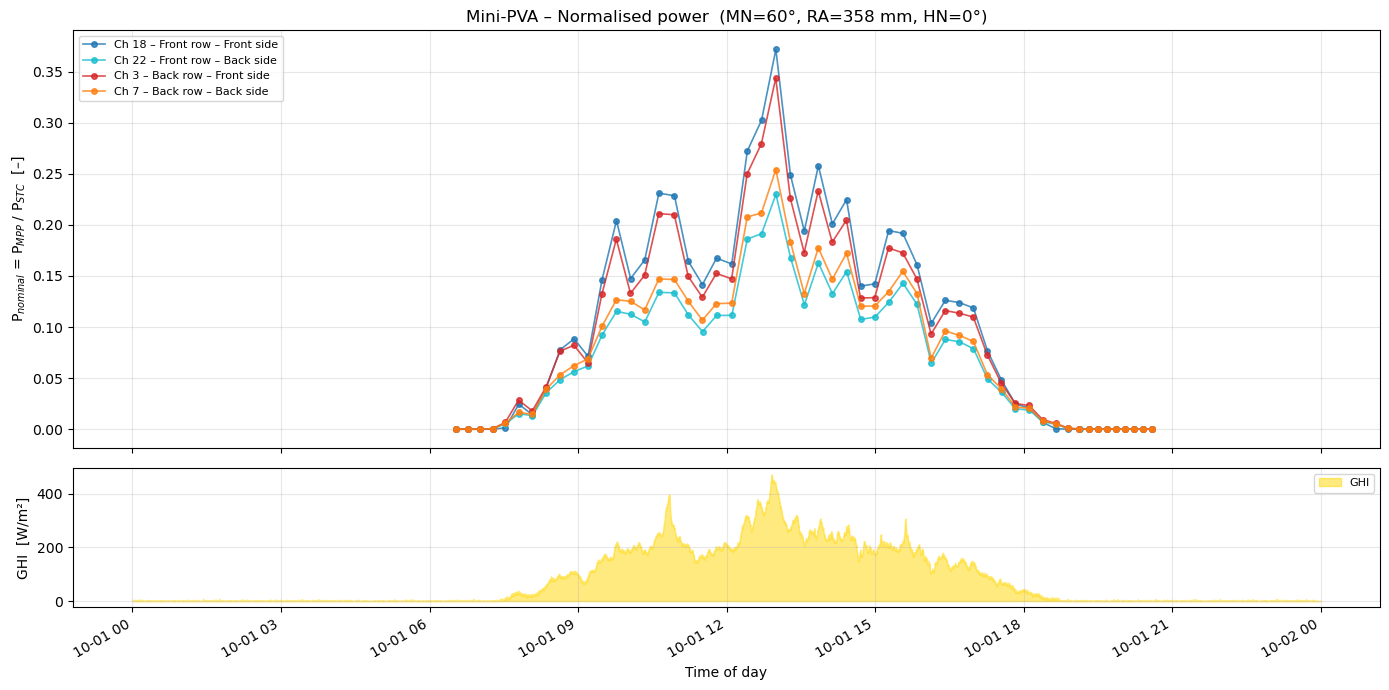

In [7]:
MN_SEL = 60    # module tilt angle [°]
RA_SEL = 358   # row spacing [mm]
HN_SEL = 0     # ground slope [°]

df_plot = df_rel[
    (df_rel['MN'] == MN_SEL) &
    (df_rel['RA'] == RA_SEL) &
    (df_rel['HN'] == HN_SEL)
].copy()

print(f"Configuration: MN={MN_SEL}°, RA={RA_SEL} mm, HN={HN_SEL}° → {len(df_plot)} rows")

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
ax_pv, ax_ghi = axes

for ch, label in RELEVANT_CHANNELS.items():
    grp = df_plot[df_plot['channel'] == ch].sort_values('mes_date')
    ax_pv.plot(grp['mes_date'], grp['Pnominal'],
               marker='o', markersize=4, linewidth=1.2, alpha=0.8,
               color=COLORS[ch], label=f'Ch {ch} – {label}')

ax_pv.set_ylabel('P$_{nominal}$ = P$_{MPP}$ / P$_{STC}$  [–]')
ax_pv.set_title(f'Mini-PVA – Normalised power  '
                f'(MN={MN_SEL}°, RA={RA_SEL} mm, HN={HN_SEL}°)')
ax_pv.legend(fontsize=8, loc='upper left')
ax_pv.grid(True, alpha=0.3)

# Global Horizontal Irradiance as context for the power curve shape
ax_ghi.fill_between(env_data['Timestamp'], env_data['GHI'],
                    alpha=0.5, color='gold', label='GHI')
ax_ghi.set_ylabel('GHI  [W/m²]')
ax_ghi.set_xlabel('Time of day')
ax_ghi.legend(fontsize=8)
ax_ghi.grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

#### Plot 2 – Bifaciality: front side vs back side

Compares front-side and back-side channels for each module row. The back side receives diffuse and reflected (albedo) irradiance only. At this alpine site, snow albedo significantly boosts back-side yield.

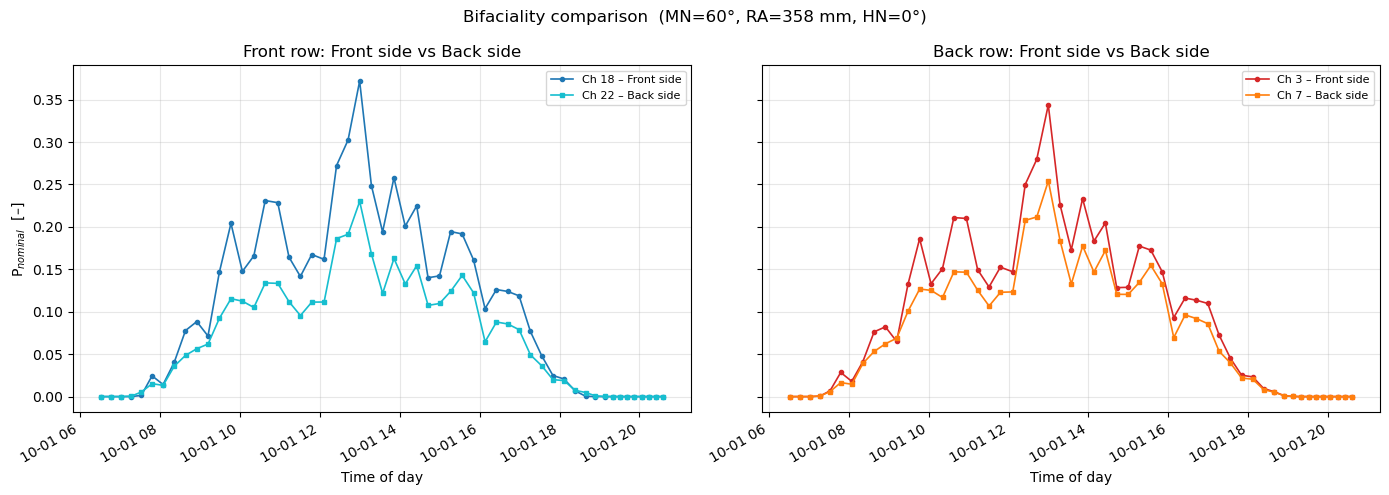

In [8]:
MN_BIF = 60
RA_BIF = 358
HN_BIF = 0

df_bif = df_rel[
    (df_rel['MN'] == MN_BIF) &
    (df_rel['RA'] == RA_BIF) &
    (df_rel['HN'] == HN_BIF)
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (ch_front, ch_back), row_name in zip(
    axes, [(18, 22), (3, 7)], ['Front row', 'Back row']
):
    front = df_bif[df_bif['channel'] == ch_front].sort_values('mes_date')
    back  = df_bif[df_bif['channel'] == ch_back].sort_values('mes_date')

    ax.plot(front['mes_date'], front['Pnominal'],
            color=COLORS[ch_front], marker='o', ms=3, lw=1.2,
            label=f'Ch {ch_front} – Front side')
    ax.plot(back['mes_date'], back['Pnominal'],
            color=COLORS[ch_back], marker='s', ms=3, lw=1.2,
            label=f'Ch {ch_back} – Back side')

    ax.set_title(f'{row_name}: Front side vs Back side')
    ax.set_xlabel('Time of day')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('P$_{nominal}$  [–]')
fig.suptitle(f'Bifaciality comparison  '
             f'(MN={MN_BIF}°, RA={RA_BIF} mm, HN={HN_BIF}°)', fontsize=12)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

#### Plot 3 – Inter-row shading: front row vs back row

Compares front and back module rows for each measurement side. The back row receives less direct irradiance due to inter-row shading, especially at low sun angles (morning/evening and winter months). Uses the same configuration as Plot 2.

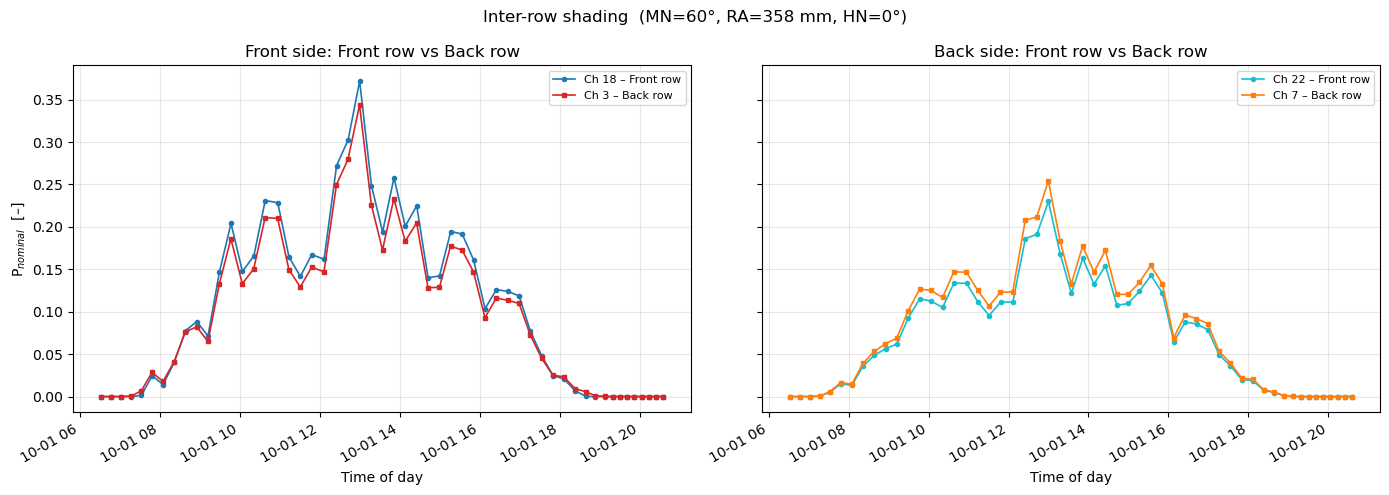

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (ch_fr, ch_br), side_name in zip(
    axes, [(18, 3), (22, 7)], ['Front side', 'Back side']
):
    fr = df_bif[df_bif['channel'] == ch_fr].sort_values('mes_date')
    br = df_bif[df_bif['channel'] == ch_br].sort_values('mes_date')

    ax.plot(fr['mes_date'], fr['Pnominal'],
            color=COLORS[ch_fr], marker='o', ms=3, lw=1.2,
            label=f'Ch {ch_fr} – Front row')
    ax.plot(br['mes_date'], br['Pnominal'],
            color=COLORS[ch_br], marker='s', ms=3, lw=1.2,
            label=f'Ch {ch_br} – Back row')

    ax.set_title(f'{side_name}: Front row vs Back row')
    ax.set_xlabel('Time of day')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('P$_{nominal}$  [–]')
fig.suptitle(f'Inter-row shading  '
             f'(MN={MN_BIF}°, RA={RA_BIF} mm, HN={HN_BIF}°)', fontsize=12)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

#### Plot 4 – Effect of module tilt angle (MN)

Channel 18 (front row, front side) at fixed RA=688 mm and HN=0°. Each line represents a different absolute module tilt angle. Flatter angles (lower MN) intercept more radiation in winter/alpine conditions.

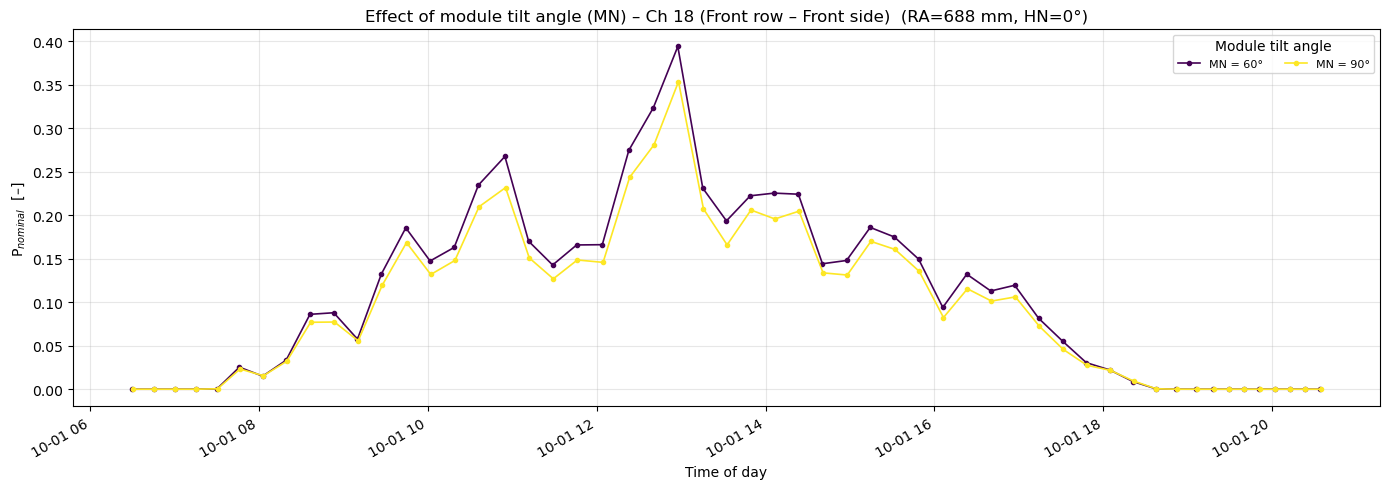

In [10]:
CH_ANGLE     = 18    # front row, front side
RA_SEL_ANGLE = 688   # widest row spacing → minimal shading influence
HN_SEL_ANGLE = 0     # flat ground → isolates MN effect

df_angle = df_rel[
    (df_rel['channel'] == CH_ANGLE) &
    (df_rel['RA'] == RA_SEL_ANGLE) &
    (df_rel['HN'] == HN_SEL_ANGLE)
].copy()

mn_values = sorted(df_angle['MN'].unique())
cmap      = plt.cm.viridis(np.linspace(0, 1, len(mn_values)))

fig, ax = plt.subplots(figsize=(14, 5))

for mn, color in zip(mn_values, cmap):
    grp = df_angle[df_angle['MN'] == mn].sort_values('mes_date')
    ax.plot(grp['mes_date'], grp['Pnominal'],
            marker='o', ms=3, lw=1.2, color=color,
            label=f'MN = {mn}°')

ax.set_ylabel('P$_{nominal}$  [–]')
ax.set_xlabel('Time of day')
ax.set_title(f'Effect of module tilt angle (MN) – '
             f'Ch {CH_ANGLE} ({RELEVANT_CHANNELS[CH_ANGLE]})  '
             f'(RA={RA_SEL_ANGLE} mm, HN={HN_SEL_ANGLE}°)')
ax.legend(fontsize=8, title='Module tilt angle', ncol=4)
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

#### Plot 5 – Mini-PVA vs Large Installation

The large installation has 6 fixed module groups at known tilt angles (30°–90°). Mini-PVA measurements at the matching MN value are overlaid for comparison.

**Matching strategy:**
- Monofacial modules (A, B, C, F) → front-side channels only (Ch 18, 3)
- Bifacial modules (D, E) → front + back combined per row: P_bif = P_front + P_back

Mini-PVA channels are measured sequentially (~1 s apart), so timestamps are rounded to the nearest minute before pairing front and back sides.

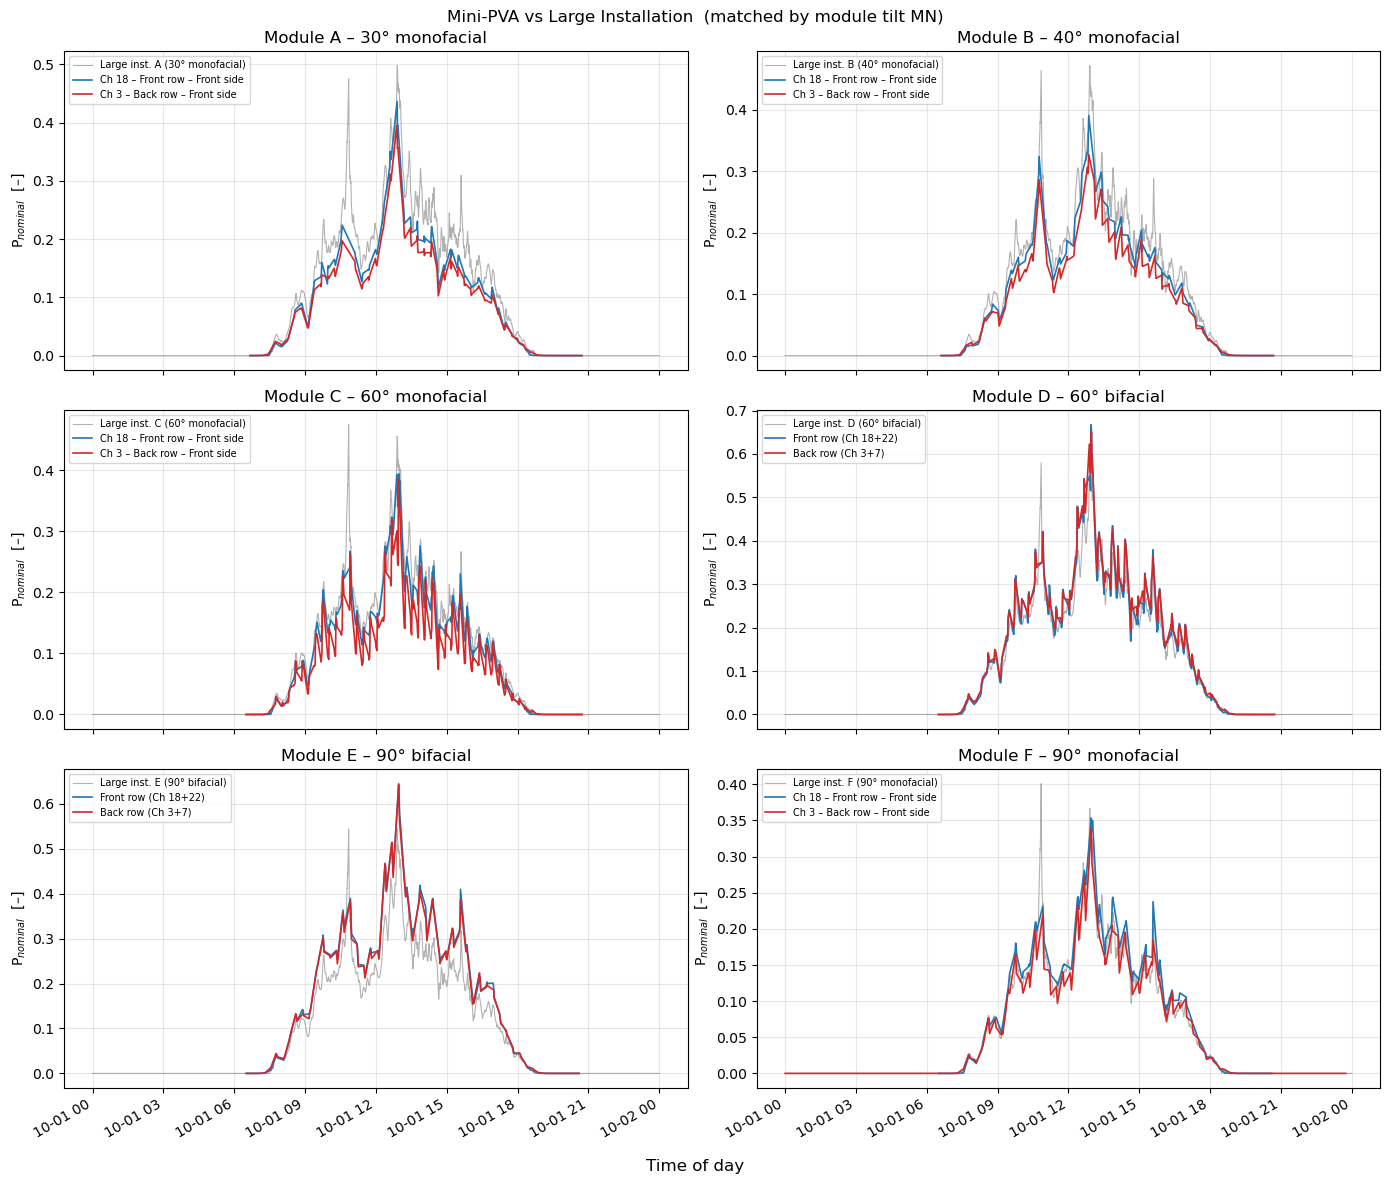

In [11]:
LARGE_MODULES = {
    'A': {'MN': 30, 'type': 'mono', 'desc': '30° monofacial'},
    'B': {'MN': 40, 'type': 'mono', 'desc': '40° monofacial'},
    'C': {'MN': 60, 'type': 'mono', 'desc': '60° monofacial'},
    'D': {'MN': 60, 'type': 'bif',  'desc': '60° bifacial'},
    'E': {'MN': 90, 'type': 'bif',  'desc': '90° bifacial'},
    'F': {'MN': 90, 'type': 'mono', 'desc': '90° monofacial'},
}

large_plot = largeinstallation.set_index('Timestamp')

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
axes = axes.flatten()

for i, (mod, cfg) in enumerate(LARGE_MODULES.items()):
    ax        = axes[i]
    mn_target = cfg['MN']
    mod_type  = cfg['type']

    # Large installation reference (grey background, continuous 10 s data)
    ax.plot(large_plot.index, large_plot[f'Pnorm {mod}'],
            color='grey', linewidth=0.8, alpha=0.6,
            label=f'Large inst. {mod} ({cfg["desc"]})')

    # Mini-PVA data filtered to matching MN (all RA and HN values included)
    df_match = df_rel[df_rel['MN'] == mn_target].copy()

    if mod_type == 'mono':
        # Monofacial: front-side channels only
        for ch in [18, 3]:
            grp = df_match[df_match['channel'] == ch].sort_values('mes_date')
            if len(grp) > 0:
                ax.plot(grp['mes_date'], grp['Pnominal'],
                        color=COLORS[ch], lw=1.2,
                        label=f'Ch {ch} – {RELEVANT_CHANNELS[ch]}')

    else:
        # Bifacial: pair front + back side per row
        # Round to nearest minute to align sequentially measured channels
        df_match['mes_date_round'] = df_match['mes_date'].dt.round('min')

        for (ch_f, ch_b), row_name, clr in zip(
            [(18, 22), (3, 7)],
            ['Front row', 'Back row'],
            ['tab:blue', 'tab:red']
        ):
            front = df_match[df_match['channel'] == ch_f][
                ['mes_date', 'mes_date_round', 'RA', 'HN', 'Pnominal']
            ].rename(columns={'Pnominal': 'P_front'})

            back = df_match[df_match['channel'] == ch_b][
                ['mes_date_round', 'RA', 'HN', 'Pnominal']
            ].rename(columns={'Pnominal': 'P_back'})

            # Merge on rounded timestamp + configuration to align measurements
            merged = front.merge(back, on=['mes_date_round', 'RA', 'HN'], how='inner')
            merged['P_bif'] = merged['P_front'] + merged['P_back']
            merged = merged.sort_values('mes_date')

            if len(merged) > 0:
                ax.plot(merged['mes_date'], merged['P_bif'],
                        color=clr, lw=1.2,
                        label=f'{row_name} (Ch {ch_f}+{ch_b})')

    ax.set_title(f'Module {mod} – {cfg["desc"]}')
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_ylabel('P$_{nominal}$  [–]')

fig.supxlabel('Time of day')
fig.suptitle('Mini-PVA vs Large Installation  (matched by module tilt MN)', fontsize=12)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

---
# Part 2: Multi-Day Analysis (Week 2/3)

We now extend the analysis to the full winter period (Oct 2024 – Mar 2025). The data structure is the same, but working with 6 months introduces new challenges:

| Challenge | Solution |
|-----------|----------|
| 180 separate daily CSV files | `glob` + `pd.concat` |
| DST transition (27.10.2024) causes ambiguous timestamps | `ambiguous='NaT'` → drop affected rows |
| MN values > 1000 (uint16 overflow, e.g. 65516 = −20°) | Subtract 65536 |
| MN = 0 (homing/night position, no yield) | Drop rows |
| Overnight interpolation creates false values | Day-wise interpolation |

The `stc_powers` table and the `RELEVANT_CHANNELS` / `COLORS` constants are reused from Part 1.

## 7. Data Loading (Multi-Day)

The multi-day data comes as 180 separate daily CSV files for the Mini-PVA, plus single large CSV files for the environmental and large installation data.

> `stc_powers` is already loaded from Part 1 and is reused directly here.

In [12]:
LAT, LON, ALT = 46.838, 9.813, 2480   # latitude [°N], longitude [°E], altitude [m]
TZ = "Europe/Zurich"

In [13]:
# stc_powers is already loaded in Part 1 and reused here

# Mini-PVA: one CSV per day → load all 180 files and concatenate into one DataFrame
files = sorted(glob.glob('../data/raw/mini_pva_daily/*.csv'))
print(f"Mini-PVA daily files found: {len(files)}")
minipva = pd.concat(
    [pd.read_csv(f, sep=';', decimal=',') for f in files],
    ignore_index=True
)

# Environmental data (GHI, DNI, zenith, air temperature) for the full period
env_data_full = pd.read_csv('../data/raw/environmental_data.csv', sep=';', decimal=',')

# Large installation data (normalised power for 6 module groups A–F)
largeinstallation_full = pd.read_csv(
    '../data/raw/largeInstallation_measurementData.csv', sep=';', decimal=','
)

print(minipva.info())
print(env_data_full.info())
print(largeinstallation_full.info())

Mini-PVA daily files found: 180
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 951999 entries, 0 to 951998
Data columns (total 15 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   ID.Results  951999 non-null  float64
 1   mes_date    951999 non-null  object 
 2   ID.Modul    951999 non-null  object 
 3   channel     951999 non-null  object 
 4   U0          951999 non-null  float64
 5   Ik          951999 non-null  float64
 6   Pmpp        951999 non-null  float64
 7   FF          927520 non-null  float64
 8   Ghor        951999 non-null  object 
 9   Tluft       951999 non-null  object 
 10  RA          951999 non-null  object 
 11  MN          951999 non-null  object 
 12  HN          951999 non-null  object 
 13  Res         951999 non-null  object 
 14  mes_time    951999 non-null  object 
dtypes: float64(5), object(10)
memory usage: 108.9+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1546561 entries, 0 to 1546560
Dat

## 8. Mini-PVA Data Cleaning

In [14]:
# mes_date already contains full datetime — mes_time is redundant → drop it
minipva.drop(columns=['mes_time'], inplace=True)

# Parse datetime — explicit format avoids ambiguity warnings
minipva['mes_date'] = pd.to_datetime(
    minipva['mes_date'],
    format='%m/%d/%Y %I:%M:%S %p',
    errors='coerce'
)

# Convert configuration columns from object to numeric
minipva['channel'] = pd.to_numeric(minipva['channel'], errors='coerce').astype('Int64')
minipva['RA']      = pd.to_numeric(minipva['RA'],      errors='coerce')
minipva['MN']      = pd.to_numeric(minipva['MN'],      errors='coerce')
minipva['HN']      = pd.to_numeric(minipva['HN'],      errors='coerce')

# Tluft: stored as "15.1°C" → strip unit and convert to float
minipva['Tluft'] = (
    minipva['Tluft'].astype(str)
    .str.replace('°C', '', regex=False)
    .str.strip()
    .astype(float)
)

# Ghor: may use comma as decimal separator → normalise to dot
minipva['Ghor'] = pd.to_numeric(
    minipva['Ghor'].astype(str).str.replace(',', '.', regex=False),
    errors='coerce'
)

n_failed = minipva['mes_date'].isna().sum()
if n_failed > 0:
    print(f"⚠  {n_failed} timestamps could not be parsed")

# Must sort by time BEFORE localising to avoid AmbiguousTimeError.
# ambiguous='NaT': rows in the DST gap (27.10.2024 02:00–03:00) → dropped.
minipva.sort_values('mes_date', inplace=True)
minipva.reset_index(drop=True, inplace=True)

minipva['mes_date'] = minipva['mes_date'].dt.tz_localize(
    'Europe/Zurich', ambiguous='NaT', nonexistent='shift_forward'
)
n_ambiguous = minipva['mes_date'].isna().sum()
print(f"Ambiguous timestamps (DST transition): {n_ambiguous} rows → dropped")
minipva.dropna(subset=['mes_date'], inplace=True)

minipva.sort_values(['channel', 'mes_date'], inplace=True)
minipva.reset_index(drop=True, inplace=True)

# MN: unsigned 16-bit integer overflow (e.g. 65516 = −20° in signed int16)
overflow_mask = minipva['MN'] > 1000
minipva.loc[overflow_mask, 'MN'] = minipva.loc[overflow_mask, 'MN'] - 65536
print(f"MN overflow corrections: {overflow_mask.sum()} rows")

# Negative MN = homing/night position → drop
invalid_mn = minipva['MN'] < 0
print(f"Negative MN (homing/night position): {invalid_mn.sum()} rows → dropped")
minipva = minipva[~invalid_mn].copy()

# RA: hardware limits 115–719 mm per device documentation
invalid_ra = (minipva['RA'] < 115) | (minipva['RA'] > 719)
print(f"Invalid RA values (outside 115–719 mm): {invalid_ra.sum()} rows → dropped")
minipva = minipva[~invalid_ra].copy()

# MN = 0: safe/night position (Pmpp ≈ 0, no yield) → drop
invalid_mn0 = minipva['MN'] == 0
print(f"MN = 0 (safe/night position): {invalid_mn0.sum()} rows → dropped")
minipva = minipva[~invalid_mn0].copy()

minipva.reset_index(drop=True, inplace=True)

print(f"\nAfter cleaning: {len(minipva):,} rows")
print(f"  MN values: {sorted(minipva['MN'].dropna().unique())}")
print(f"  RA values: {sorted(minipva['RA'].dropna().unique())}")
print(f"  HN values: {sorted(minipva['HN'].dropna().unique())}")

# STC normalisation: guard prevents double-merging if cell is re-run
stc_powers['Channel'] = stc_powers['Channel'].astype(int)
if 'STC_Power_mW' not in minipva.columns:
    minipva = minipva.merge(stc_powers, left_on='channel', right_on='Channel', how='left')
    minipva.drop(columns=['Channel'], inplace=True)

minipva['Pnominal'] = minipva['Pmpp'] / minipva['STC_Power_mW']

print(f"\nSTC normalisation: {minipva['Pnominal'].isna().sum()} rows without STC value")
print(minipva[['channel', 'Pmpp', 'STC_Power_mW', 'Pnominal']].head(5))

Ambiguous timestamps (DST transition): 8 rows → dropped
MN overflow corrections: 7 rows
Negative MN (homing/night position): 7 rows → dropped
Invalid RA values (outside 115–719 mm): 0 rows → dropped
MN = 0 (safe/night position): 7936 rows → dropped

After cleaning: 944,048 rows
  MN values: [np.int64(10), np.int64(20), np.int64(30), np.int64(40), np.int64(45), np.int64(50), np.int64(60), np.int64(70), np.int64(80), np.int64(90)]
  RA values: [np.int64(115), np.int64(137), np.int64(166), np.int64(205), np.int64(263), np.int64(358), np.int64(544), np.int64(670), np.int64(688), np.int64(700)]
  HN values: [np.int64(0), np.int64(10), np.int64(20), np.int64(30), np.int64(40)]

STC normalisation: 0 rows without STC value
   channel      Pmpp  STC_Power_mW  Pnominal
0        1    1.6968       2643.35  0.000642
1        1   10.0936       2643.35  0.003818
2        1  236.0527       2643.35  0.089301
3        1  332.4423       2643.35  0.125766
4        1  694.7178       2643.35  0.262817


## 9. Environmental & Large Installation Cleaning

In [15]:
# Environmental data
env_data_full.dropna(subset=['Timestamp'], inplace=True)
env_data_full['Timestamp'] = pd.to_datetime(env_data_full['Timestamp'], format='mixed')
env_data_full.sort_values('Timestamp', inplace=True)
env_data_full['Timestamp'] = env_data_full['Timestamp'].dt.tz_localize(
    'Europe/Zurich', ambiguous='NaT', nonexistent='shift_forward'
)
env_data_full.dropna(subset=['Timestamp'], inplace=True)
env_data_full.reset_index(drop=True, inplace=True)

print(f"Environmental data: {len(env_data_full):,} rows | "
      f"{env_data_full['Timestamp'].min()} → {env_data_full['Timestamp'].max()}")

# Large installation data
largeinstallation_full['Timestamp'] = pd.to_datetime(
    largeinstallation_full['Timestamp'], format='mixed'
)
largeinstallation_full.sort_values('Timestamp', inplace=True)
largeinstallation_full['Timestamp'] = largeinstallation_full['Timestamp'].dt.tz_localize(
    'Europe/Zurich', ambiguous='NaT', nonexistent='shift_forward'
)
largeinstallation_full.dropna(subset=['Timestamp'], inplace=True)
largeinstallation_full.columns = [
    c.replace(' ', '_') for c in largeinstallation_full.columns
]
largeinstallation_full.reset_index(drop=True, inplace=True)

print(f"Large installation: {len(largeinstallation_full):,} rows | "
      f"{largeinstallation_full['Timestamp'].min()} → "
      f"{largeinstallation_full['Timestamp'].max()}")

Environmental data: 1,545,841 rows | 2024-10-01 00:00:00+02:00 → 2025-03-31 00:00:00+02:00
Large installation: 1,545,481 rows | 2024-10-01 00:00:00+02:00 → 2025-03-31 00:00:00+02:00


## 10. Day-wise Interpolation

Standard time-based interpolation would bridge overnight gaps, creating physically meaningless values (e.g. interpolating GHI from 23:00 to 07:00). Solution: interpolate only within each calendar day.

In [16]:
def interpolate_by_day(source_df, source_ts_col, target_timestamps):
    """
    Interpolate source_df onto target_timestamps using time-based linear
    interpolation, restricted to within each calendar day.

    Parameters
    ----------
    source_df : pd.DataFrame
        Source data with a timezone-aware datetime column.
    source_ts_col : str
        Name of the timestamp column in source_df.
    target_timestamps : pd.DatetimeIndex
        Target timestamps to interpolate to (Mini-PVA measurement times).

    Returns
    -------
    pd.DataFrame
        Interpolated values at target_timestamps. Rows with no source data
        on the same calendar day remain NaN.
    """
    data_cols = [c for c in source_df.columns if c != source_ts_col]
    result = pd.DataFrame(index=target_timestamps, columns=data_cols, dtype=float)
    result.index.name = source_ts_col

    target_dates = pd.Series(target_timestamps).dt.date.unique()

    for date in target_dates:
        day_targets = target_timestamps[
            pd.Series(target_timestamps).dt.date.values == date
        ]
        day_source = source_df[source_df[source_ts_col].dt.date == date].copy()

        if len(day_source) == 0 or len(day_targets) == 0:
            continue

        day_source = day_source.set_index(source_ts_col)
        day_source = day_source.groupby(level=0).mean()  # duplicate timestamps → mean

        combined_index = day_source.index.union(day_targets).sort_values()
        reindexed      = day_source.reindex(combined_index)
        interpolated   = reindexed.interpolate(method='time')
        result.loc[day_targets, data_cols] = (
            interpolated.loc[day_targets, data_cols].values
        )

    for col in result.columns:
        try:
            result[col] = pd.to_numeric(result[col])
        except (ValueError, TypeError):
            pass
    return result


# Target timestamps: all unique Mini-PVA measurement times (sorted)
target_ts = pd.DatetimeIndex(sorted(minipva['mes_date'].unique()))

env_interp = interpolate_by_day(env_data_full.copy(), 'Timestamp', target_ts)

largeinstallation_full_copy = largeinstallation_full.copy()
largeinstallation_full_copy.columns = [
    'Timestamp' if c == 'Timestamp' else c
    for c in largeinstallation_full_copy.columns
]
large_interp = interpolate_by_day(largeinstallation_full_copy, 'Timestamp', target_ts)

print(f"Interpolation complete:")
print(f"  Env:   {env_interp.notna().any(axis=1).sum()} of {len(target_ts)} timestamps")
print(f"  Large: {large_interp.notna().any(axis=1).sum()} of {len(target_ts)} timestamps")

combined = minipva.copy()
combined = combined.merge(env_interp,   left_on='mes_date', right_index=True, how='left')
combined = combined.merge(large_interp, left_on='mes_date', right_index=True, how='left')

# Flag rows where environmental data could not be interpolated (0.8% of rows)
combined['env_missing'] = combined['GHI'].isna()

print(f"\nCombined shape: {combined.shape}")
print(f"Missing environmental data: {combined['env_missing'].sum():,} rows "
      f"({combined['env_missing'].mean()*100:.1f}%)")

Interpolation complete:
  Env:   936657 of 944048 timestamps
  Large: 936657 of 944048 timestamps

Combined shape: (944048, 34)
Missing environmental data: 7,391 rows (0.8%)


## 11. Solar Position (pvlib)

Solar position is calculated analytically from site coordinates and time. `sun_up = True` (elevation > 0°) is used as a filter for yield integration, only measurements during daylight are included.

In [17]:
location = pvlib.location.Location(
    latitude=LAT, longitude=LON, altitude=ALT, tz=TZ
)

solpos = location.get_solarposition(target_ts)
solpos_df = solpos[['zenith', 'azimuth', 'elevation']].rename(columns={
    'zenith':    'solar_zenith',
    'azimuth':   'solar_azimuth',
    'elevation': 'solar_elevation',
})
solpos_df['sun_up'] = solpos_df['solar_elevation'] > 0

combined = combined.merge(solpos_df, left_on='mes_date', right_index=True, how='left')

print(f"Measurements with sun above horizon: {combined['sun_up'].sum():,} "
      f"({combined['sun_up'].mean()*100:.1f}%)")

Measurements with sun above horizon: 836,400 (88.6%)


## 12. GHI Variability Index

A 2-minute rolling standard deviation of GHI serves as a proxy for cloud variability. High values indicate rapidly changing cloud cover; low values indicate clear or fully overcast sky.

In [18]:
env_var = env_data_full.set_index('Timestamp').copy()
env_var['GHI_std_2min'] = (
    env_var['GHI']
    .rolling('2min', min_periods=3)   # at least 3 samples (~30 s) required
    .std()
)

ghi_std_interp = interpolate_by_day(
    env_var[['GHI_std_2min']].reset_index().rename(columns={'index': 'Timestamp'}),
    'Timestamp', target_ts
)
combined = combined.merge(ghi_std_interp, left_on='mes_date', right_index=True, how='left')

print("GHI variability index calculated (2-min rolling std)")

GHI variability index calculated (2-min rolling std)


> **Note on the data exclusion log:** A data exclusion log was provided alongside the raw data. However, due to inconsistent formatting and unclear entries, we chose not to apply it programmatically. Instead, we rely on the missing-day detection below and the hardware-based cleaning steps (MN overflow, invalid RA, MN=0) to identify and remove bad data. Any remaining noise is expected to average out over the full 6-month period.

## 13. Yield Calculation

Daily yield [Wh/Wp] is computed by integrating Pnominal over time using the trapezoidal rule, restricted to daylight hours (`sun_up = True`).

In [19]:
def calculate_daily_yield(df, channel, MN=None, RA=None, HN=None,
                           date_start=None, date_end=None):
    """
    Calculate daily yield [Wh/Wp] for a given channel and optional
    configuration filters. Integration: trapezoidal rule, daylight only.

    Parameters
    ----------
    df : pd.DataFrame
        Combined dataset.
    channel : int
        Channel number (e.g. 18 = front row, front side).
    MN, RA, HN : float or None
        Optional configuration filters.
    date_start, date_end : str or None
        Optional date range ('YYYY-MM-DD').

    Returns
    -------
    pd.DataFrame
        Columns: date, yield_Wh_Wp, sun_hours, n_measurements.
    """
    sub = df[df['channel'] == channel].copy()
    if MN         is not None: sub = sub[sub['MN'] == MN]
    if RA         is not None: sub = sub[sub['RA'] == RA]
    if HN         is not None: sub = sub[sub['HN'] == HN]
    if date_start is not None:
        sub = sub[sub['mes_date'].dt.date >= pd.Timestamp(date_start).date()]
    if date_end   is not None:
        sub = sub[sub['mes_date'].dt.date <= pd.Timestamp(date_end).date()]

    sub = sub[sub['sun_up'] == True].copy()
    sub = sub.sort_values('mes_date')
    sub['date'] = sub['mes_date'].dt.date

    results = []
    for date, grp in sub.groupby('date'):
        grp   = grp.sort_values('mes_date')
        t_sec = grp['mes_date'].astype('int64') / 1e9   # Unix time [s]
        p     = grp['Pnominal'].values                   # normalised power [–]

        # Trapezoidal integration: (W/Wp × s) / 3600 = Wh/Wp
        yield_Wh_Wp = np.trapezoid(p, t_sec) / 3600
        sun_hours   = (t_sec.iloc[-1] - t_sec.iloc[0]) / 3600

        results.append({
            'date':           date,
            'yield_Wh_Wp':    yield_Wh_Wp,
            'sun_hours':      sun_hours,
            'n_measurements': len(grp),
        })

    return pd.DataFrame(results)


def period_yield(df, channel, MN=None, RA=None, HN=None,
                 date_start=None, date_end=None):
    """Sum daily yields over a period [Wh/Wp]."""
    daily = calculate_daily_yield(df, channel, MN, RA, HN, date_start, date_end)
    return daily['yield_Wh_Wp'].sum()


print("── Example: Yield for October 2024 ──────────────────────────────────────")
for ch, label in RELEVANT_CHANNELS.items():
    y = period_yield(combined, ch, date_start='2024-10-01', date_end='2024-10-31')
    print(f"  Ch {ch:2d} ({label}): {y:.3f} Wh/Wp")

── Example: Yield for October 2024 ──────────────────────────────────────
  Ch 18 (Front row – Front side): 92.035 Wh/Wp
  Ch 22 (Front row – Back side): 30.757 Wh/Wp
  Ch  3 (Back row – Front side): 85.601 Wh/Wp
  Ch  7 (Back row – Back side): 33.666 Wh/Wp


## 14. Helper Function

In [20]:
def filter_combined(df, channel=None, MN=None, RA=None, HN=None,
                    date_start=None, date_end=None, sun_up_only=True):
    """
    Filter the combined dataset by channel, configuration, and date range.

    Parameters
    ----------
    df : pd.DataFrame
        Combined dataset.
    channel : int or None
        Channel number filter.
    MN, RA, HN : float or None
        Configuration filters.
    date_start, date_end : str or None
        Date range filters ('YYYY-MM-DD').
    sun_up_only : bool
        If True (default), restrict to daylight measurements.

    Returns
    -------
    pd.DataFrame
        Filtered and sorted subset of df.
    """
    sub = df.copy()
    if channel    is not None: sub = sub[sub['channel'] == channel]
    if MN         is not None: sub = sub[sub['MN'] == MN]
    if RA         is not None: sub = sub[sub['RA'] == RA]
    if HN         is not None: sub = sub[sub['HN'] == HN]
    if date_start is not None:
        sub = sub[sub['mes_date'].dt.date >= pd.Timestamp(date_start).date()]
    if date_end   is not None:
        sub = sub[sub['mes_date'].dt.date <= pd.Timestamp(date_end).date()]
    if sun_up_only:
        sub = sub[sub['sun_up'] == True]
    return sub.sort_values('mes_date')

## 15. Dataset Overview

In [21]:
print("── Dataset overview ──────────────────────────────────────────────────────")
print(f"Combined dataset:   {len(combined):>10,} rows")
print(f"Period:             {combined['mes_date'].min()} → {combined['mes_date'].max()}")
print(f"MN values:          {sorted(combined['MN'].dropna().unique())}")
print(f"RA values:          {sorted(combined['RA'].dropna().unique())}")
print(f"HN values:          {sorted(combined['HN'].dropna().unique())}")
print(f"Missing env. data:  {combined['env_missing'].sum():,} rows "
      f"({combined['env_missing'].mean()*100:.1f}%)")

df_rel = combined[combined['channel'].isin(RELEVANT_CHANNELS.keys())].copy()
print(f"\nRelevant channels subset: {len(df_rel):,} rows")

── Dataset overview ──────────────────────────────────────────────────────
Combined dataset:      944,048 rows
Period:             2024-10-01 00:00:29+02:00 → 2025-03-31 23:44:58+02:00
MN values:          [np.int64(10), np.int64(20), np.int64(30), np.int64(40), np.int64(45), np.int64(50), np.int64(60), np.int64(70), np.int64(80), np.int64(90)]
RA values:          [np.int64(115), np.int64(137), np.int64(166), np.int64(205), np.int64(263), np.int64(358), np.int64(544), np.int64(670), np.int64(688), np.int64(700)]
HN values:          [np.int64(0), np.int64(10), np.int64(20), np.int64(30), np.int64(40)]
Missing env. data:  7,391 rows (0.8%)

Relevant channels subset: 747,783 rows


#### Missing Mini-PVA Data Periods

The lecture notes mention that some periods have no Mini-PVA data at all (e.g. Jan 14/15). Here we identify which days in the full measurement period have zero Mini-PVA measurements, so we can flag them explicitly rather than silently ignoring them. Days with gaps could be caused by device maintenance, hardware faults, or data transmission issues. We do **not** interpolate across these gaps, they simply appear as missing in the yield calculation.

In [22]:
# Build the full expected date range for the measurement period
period_start = combined['mes_date'].min().date()
period_end   = combined['mes_date'].max().date()
all_dates    = pd.date_range(period_start, period_end, freq='D').date

# Days that actually have at least one Mini-PVA measurement
measured_dates = set(combined['mes_date'].dt.date.unique())

# Days with no data at all
missing_dates = sorted(set(all_dates) - measured_dates)

print(f"Measurement period: {period_start} → {period_end}")
print(f"Total days in period:     {len(all_dates)}")
print(f"Days with measurements:   {len(measured_dates)}")
print(f"Days with NO data:        {len(missing_dates)}")

if missing_dates:
    # Group consecutive missing days into ranges for readability
    import itertools
    from datetime import timedelta

    def group_consecutive(dates):
        """Group a sorted list of dates into consecutive ranges."""
        ranges = []
        for k, g in itertools.groupby(
            enumerate(dates), lambda x: x[1].toordinal() - x[0]
        ):
            group = list(g)
            start = group[0][1]
            end   = group[-1][1]
            ranges.append((start, end))
        return ranges

    print("\nMissing periods:")
    for start, end in group_consecutive(missing_dates):
        n_days = (end - start).days + 1
        if start == end:
            print(f"  {start}  (1 day)")
        else:
            print(f"  {start} → {end}  ({n_days} days)")

# Add a boolean flag to the combined dataframe for convenience
combined['minipva_day_missing'] = combined['mes_date'].dt.date.isin(missing_dates)
print(f"\nFlag 'minipva_day_missing' added to combined dataframe.")

Measurement period: 2024-10-01 → 2025-03-31
Total days in period:     182
Days with measurements:   174
Days with NO data:        8

Missing periods:
  2024-12-07  (1 day)
  2024-12-20 → 2024-12-24  (5 days)
  2025-01-14 → 2025-01-15  (2 days)

Flag 'minipva_day_missing' added to combined dataframe.


## 16. Visualisations

Six plots exploring the multi-day dataset:

| Plot | What it shows |
|------|---------------|
| 1 | Daily yield over the full period – seasonal overview |
| 2 | Pnominal + GHI over several days – multi-day detail view |
| 3 | Daily yield vs module tilt angle MN – boxplot distribution |
| 4 | Daily yield vs GHI variability – scatter |
| 5 | Solar position (elevation & azimuth) – example day |
| 6 | Daily yield calendar – full period heatmap |

#### Plot 1 – Daily yield over the full measurement period

Shows the seasonal trend: yield drops from October toward December (shortest days, lowest sun angles) and recovers toward March.

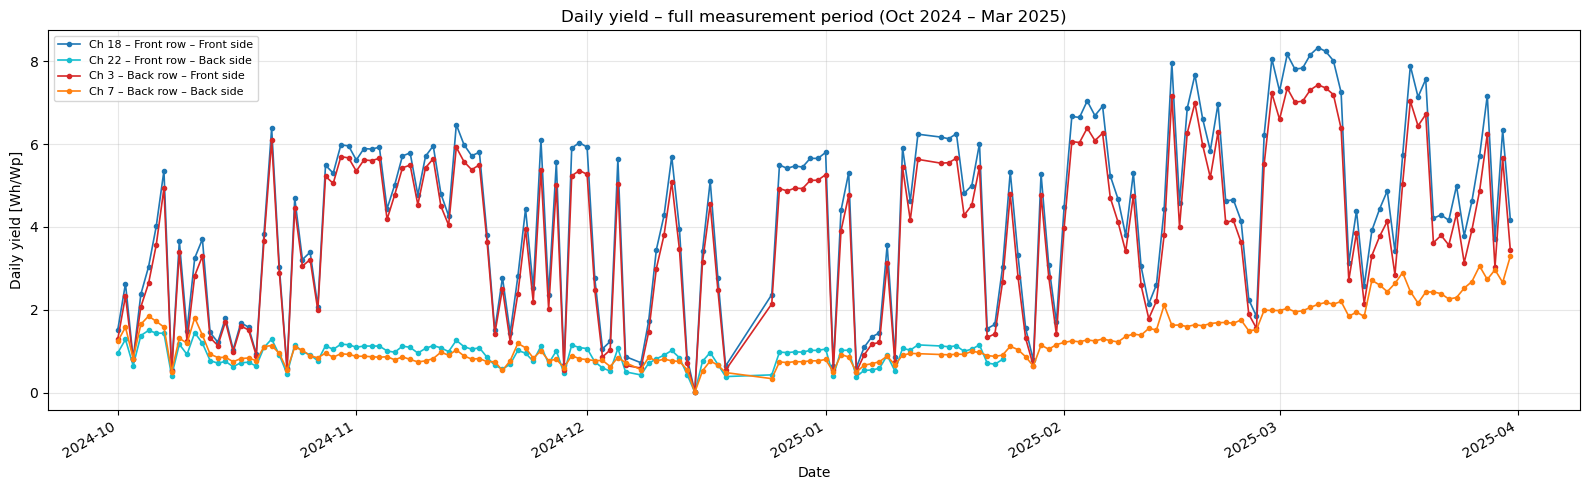

In [23]:
fig, ax = plt.subplots(figsize=(16, 5))

for ch, label in RELEVANT_CHANNELS.items():
    daily = calculate_daily_yield(df_rel, ch)
    if len(daily) > 0:
        ax.plot(pd.to_datetime(daily['date']), daily['yield_Wh_Wp'],
                marker='o', ms=3, lw=1.2, color=COLORS[ch],
                label=f'Ch {ch} – {label}')

ax.set_ylabel('Daily yield [Wh/Wp]')
ax.set_xlabel('Date')
ax.set_title('Daily yield – full measurement period (Oct 2024 – Mar 2025)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

#### Plot 2 – Pnominal time series + GHI over several days

Multi-day view of normalised power for a fixed configuration. Grey vertical lines mark calendar day boundaries. The GHI panel shows how cloud cover drives day-to-day yield variation.

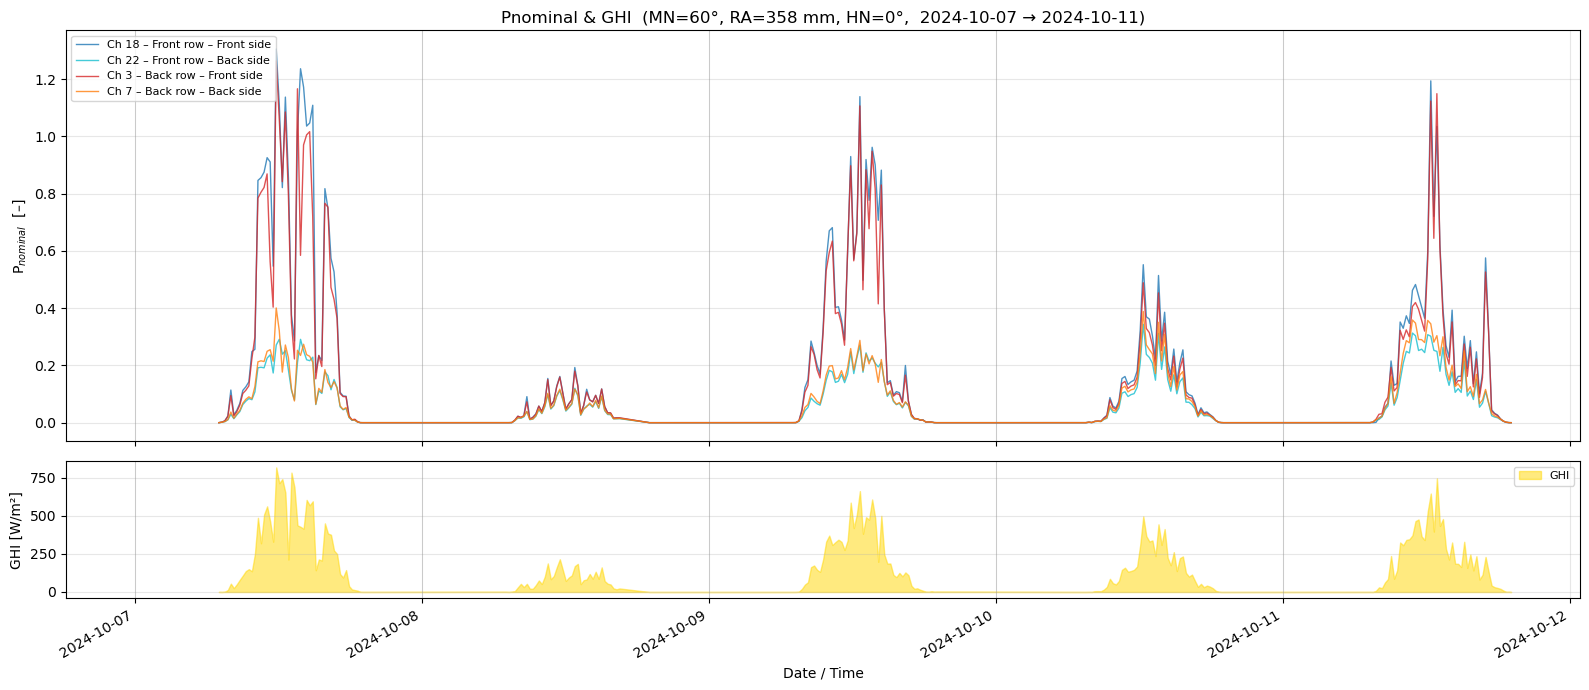

In [24]:
MN_SEL, RA_SEL, HN_SEL = 60, 358, 0
DATE_START, DATE_END    = '2024-10-07', '2024-10-11'

df_plot = filter_combined(df_rel, MN=MN_SEL, RA=RA_SEL, HN=HN_SEL,
                          date_start=DATE_START, date_end=DATE_END,
                          sun_up_only=False)

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
ax_pv, ax_ghi = axes

for ch, label in RELEVANT_CHANNELS.items():
    grp = df_plot[df_plot['channel'] == ch].sort_values('mes_date')
    ax_pv.plot(grp['mes_date'], grp['Pnominal'],
               lw=1.0, alpha=0.8, color=COLORS[ch],
               label=f'Ch {ch} – {label}')

ax_pv.set_ylabel('P$_{nominal}$  [–]')
ax_pv.set_title(f'Pnominal & GHI  (MN={MN_SEL}°, RA={RA_SEL} mm, HN={HN_SEL}°,  '
                f'{DATE_START} → {DATE_END})')
ax_pv.legend(fontsize=8)
ax_pv.grid(True, alpha=0.3)

ghi_plot = df_plot[df_plot['channel'] == 18].sort_values('mes_date')
ax_ghi.fill_between(ghi_plot['mes_date'], ghi_plot['GHI'],
                    alpha=0.5, color='gold', label='GHI')
ax_ghi.set_ylabel('GHI [W/m²]')
ax_ghi.set_xlabel('Date / Time')
ax_ghi.legend(fontsize=8)
ax_ghi.grid(True, alpha=0.3)

for date in pd.date_range(DATE_START, DATE_END, freq='D', tz=TZ):
    ax_pv.axvline(date,  color='grey', lw=0.5, alpha=0.4)
    ax_ghi.axvline(date, color='grey', lw=0.5, alpha=0.4)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

#### Plot 3 – Daily yield vs module tilt angle MN (boxplot)

Each boxplot shows the distribution of daily yields across all days for a given module tilt angle. Front and back side channels are shown side by side for each row.

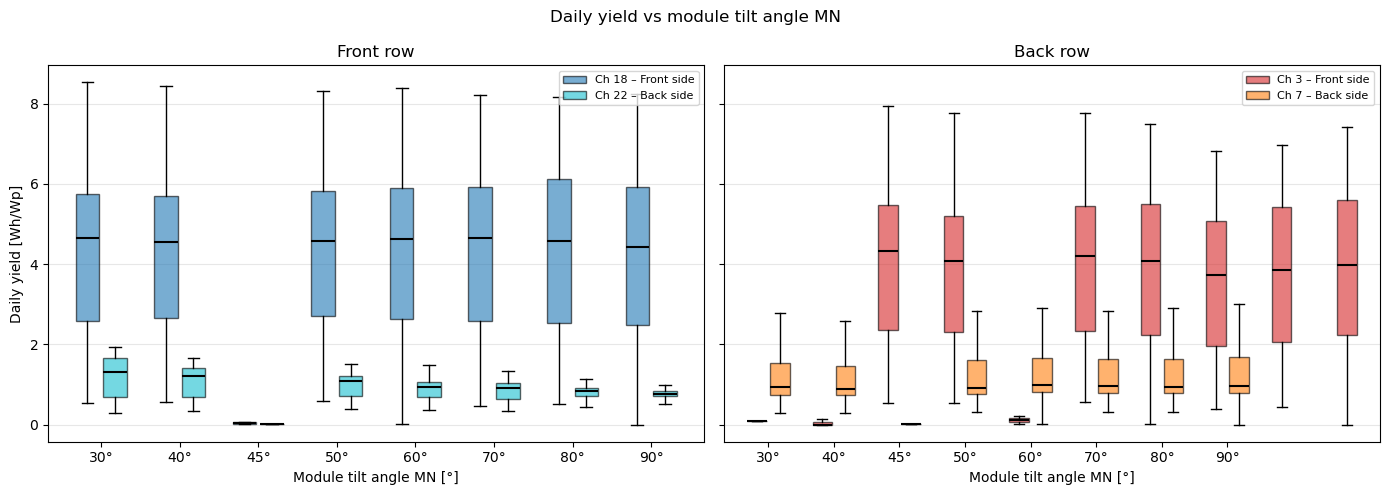

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (ch_front, ch_back), row_name in zip(
    axes, [(18, 22), (3, 7)], ['Front row', 'Back row']
):
    for ch, style, label_side in [
        (ch_front, dict(color=COLORS[ch_front]), 'Front side'),
        (ch_back,  dict(color=COLORS[ch_back]),  'Back side'),
    ]:
        mn_yields = {}
        for mn in sorted(df_rel['MN'].unique()):
            daily = calculate_daily_yield(df_rel, ch, MN=mn)
            if len(daily) > 0:
                mn_yields[mn] = daily['yield_Wh_Wp'].values

        mn_labels = sorted(mn_yields.keys())
        data      = [mn_yields[mn] for mn in mn_labels]
        # Offset front/back boxplots slightly so they don't overlap
        positions = [i + (0 if ch == ch_front else 0.35)
                     for i in range(len(mn_labels))]

        bp = ax.boxplot(data, positions=positions, widths=0.3,
                        patch_artist=True, showfliers=False,
                        medianprops=dict(color='black', lw=1.5))
        for patch in bp['boxes']:
            patch.set_facecolor(style['color'])
            patch.set_alpha(0.6)
        bp['boxes'][0].set_label(f'Ch {ch} – {label_side}')

    ax.set_xticks([i + 0.175 for i in range(len(mn_labels))])
    ax.set_xticklabels([f'{mn}°' for mn in mn_labels])
    ax.set_xlabel('Module tilt angle MN [°]')
    ax.set_title(f'{row_name}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

axes[0].set_ylabel('Daily yield [Wh/Wp]')
fig.suptitle('Daily yield vs module tilt angle MN', fontsize=12)
plt.tight_layout()
plt.show()

#### Plot 4 – Daily yield vs GHI variability (scatter)

Tests whether cloudy/variable days systematically produce lower yields. Expected pattern: clear days (low std, high GHI) → high yield; overcast days (low std, low GHI) → low yield.

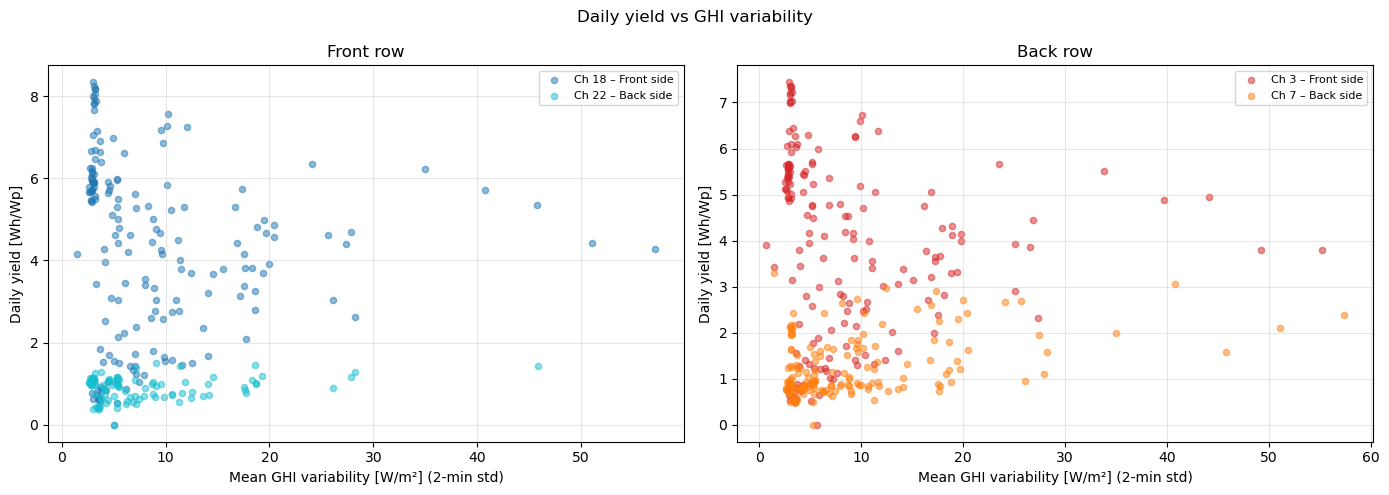

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (ch_front, ch_back), row_name in zip(
    axes, [(18, 22), (3, 7)], ['Front row', 'Back row']
):
    for ch, label_side in [(ch_front, 'Front side'), (ch_back, 'Back side')]:
        daily = calculate_daily_yield(df_rel, ch)
        if len(daily) == 0:
            continue

        # Mean GHI variability per day
        ghi_daily = (
            df_rel[df_rel['channel'] == ch]
            .assign(date=lambda x: x['mes_date'].dt.date)
            .groupby('date')['GHI_std_2min']
            .mean()
            .reset_index()
        )
        merged = daily.merge(ghi_daily, on='date', how='inner')

        ax.scatter(merged['GHI_std_2min'], merged['yield_Wh_Wp'],
                   alpha=0.5, s=20, color=COLORS[ch],
                   label=f'Ch {ch} – {label_side}')

    ax.set_xlabel('Mean GHI variability [W/m²] (2-min std)')
    ax.set_ylabel('Daily yield [Wh/Wp]')
    ax.set_title(f'{row_name}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Daily yield vs GHI variability', fontsize=12)
plt.tight_layout()
plt.show()

#### Plot 5 – Solar position (elevation & azimuth)

Example day showing the calculated solar trajectory. At this alpine site (N46.8°) in November, maximum elevation is only ~20°, relevant for understanding why flatter module tilts are optimal in winter.

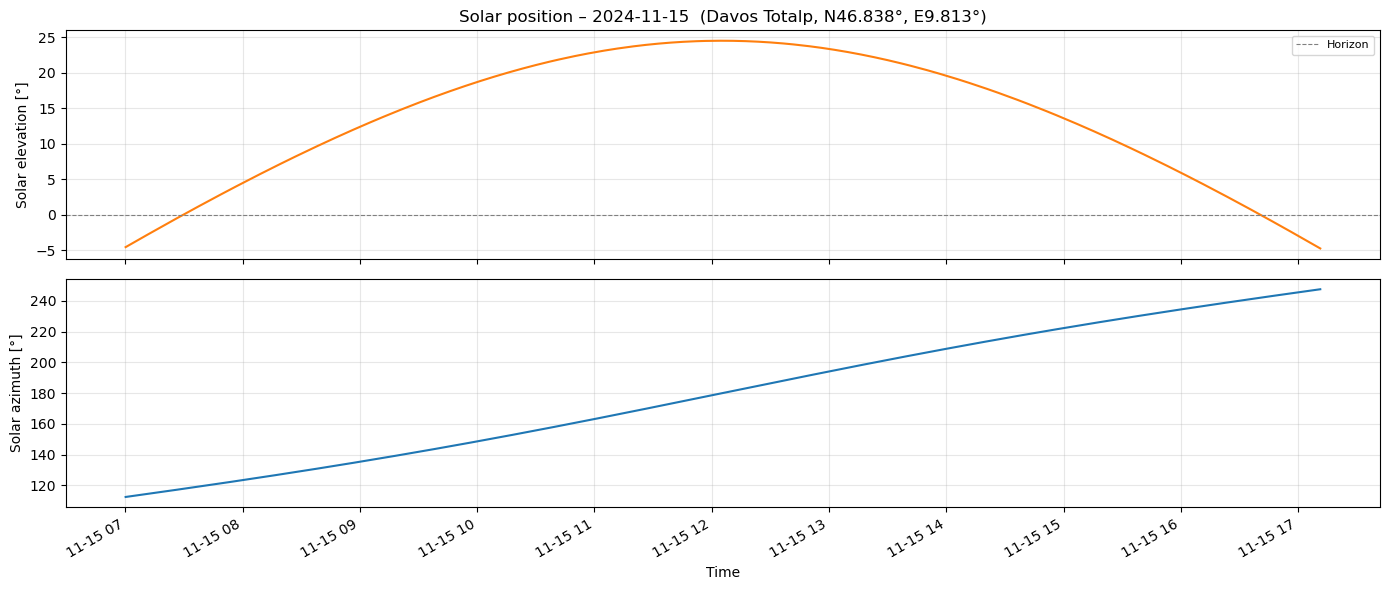

In [27]:
EXAMPLE_DATE = '2024-11-15'

sol_day = combined[
    (combined['mes_date'].dt.date == pd.Timestamp(EXAMPLE_DATE).date()) &
    (combined['channel'] == 18)   # any single channel — solar position is site-wide
].sort_values('mes_date')

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
ax_el, ax_az = axes

ax_el.plot(sol_day['mes_date'], sol_day['solar_elevation'],
           color='tab:orange', lw=1.5)
ax_el.axhline(0, color='grey', lw=0.8, linestyle='--', label='Horizon')
ax_el.set_ylabel('Solar elevation [°]')
ax_el.set_title(f'Solar position – {EXAMPLE_DATE}  '
                f'(Davos Totalp, N{LAT}°, E{LON}°)')
ax_el.legend(fontsize=8)
ax_el.grid(True, alpha=0.3)

ax_az.plot(sol_day['mes_date'], sol_day['solar_azimuth'],
           color='tab:blue', lw=1.5)
ax_az.set_ylabel('Solar azimuth [°]')
ax_az.set_xlabel('Time')
ax_az.grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

#### Plot 6 – Daily Yield Calendar (Ch 18, Front row, Front side)

A calendar view of daily yield across the full measurement period. Each square represents one day, coloured by yield [Wh/Wp]. Note: the x-axis shows ISO week numbers. The right cluster (weeks 40–52) is October to December 2024, and the left cluster (weeks 1–14) is January to March 2025.

The weakest yields appear at the very start of the measurement period (week 40, early October), followed by a recovery through November. December shows a dip again as days shorten. The highest yields (darkest red) appear in February and March. The combination of longer days and high snow albedo boosts yield significantly in late winter. The missing data periods (December 7, December 20–24, January 14–15) appear as white gaps.


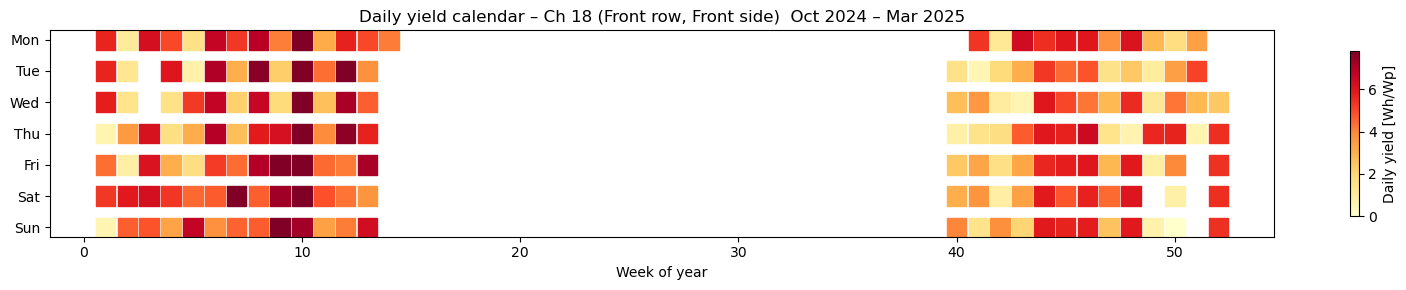

In [28]:
import matplotlib.colors as mcolors

daily = calculate_daily_yield(df_rel, 18)
daily['date'] = pd.to_datetime(daily['date'])
daily['week'] = daily['date'].dt.isocalendar().week.astype(int)
daily['dow']  = daily['date'].dt.dayofweek
daily['month'] = daily['date'].dt.month

fig, ax = plt.subplots(figsize=(16, 3))
scatter = ax.scatter(daily['week'], daily['dow'],
                     c=daily['yield_Wh_Wp'], cmap='YlOrRd',
                     s=200, marker='s',
                     vmin=0, vmax=daily['yield_Wh_Wp'].quantile(0.95))
ax.set_yticks(range(7))
ax.set_yticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
ax.set_xlabel('Week of year')
ax.set_title('Daily yield calendar – Ch 18 (Front row, Front side)  Oct 2024 – Mar 2025')
fig.colorbar(scatter, ax=ax, label='Daily yield [Wh/Wp]', shrink=0.8)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
# Part 3: Bifacial Yield & Performance Map (Week 4/5)

Building on the multi-day dataset, we now produce the final project deliverables:

| Section | Content |
|---------|--------|
| **17** | Bifacial yield calculation (front + 0.9 × back) |
| **18** | Performance map: yield vs RA, MN, HN for Group focus HN ≥ 20° |
| **19** | In-plane irradiance (POA) via pvlib |
| **20** | Regression model – aggregated yields |
| **21** | Improved model – daily yields as training data |
| **22** | Results & interpretation |

## 17. Bifacial Yield Calculation

The Mini-PVA measures front and back sides **sequentially** (not simultaneously). Bifacial yield is therefore computed at the **daily integral level**:

$$Y_\text{bif} = Y_\text{front} + 0.9 \times Y_\text{back} \quad \text{[Wh/Wp]}$$

The bifaciality factor of 0.9 is specified in the project assignment. Combining at the integral level (not instantaneous power) is physically correct because the timing offset between front and back measurements is only ~1 s.

In [29]:
BIFACIALITY = 0.9

def calculate_bifacial_yield(df, ch_front, ch_back,
                              MN=None, RA=None, HN=None,
                              date_start=None, date_end=None):
    """
    Calculate daily bifacial yield [Wh/Wp]:
        Y_bif = Y_front + 0.9 × Y_back

    Front and back are integrated separately and combined at the daily level.
    Only days present in both front and back data are included.
    """
    daily_front = calculate_daily_yield(df, ch_front, MN, RA, HN, date_start, date_end)
    daily_back  = calculate_daily_yield(df, ch_back,  MN, RA, HN, date_start, date_end)

    if len(daily_front) == 0 or len(daily_back) == 0:
        return pd.DataFrame(columns=['date', 'yield_Wh_Wp_front',
                                     'yield_Wh_Wp_back', 'yield_bifacial'])

    merged = daily_front.merge(daily_back, on='date', how='inner',
                               suffixes=('_front', '_back'))

    if len(merged) == 0:
        return pd.DataFrame(columns=['date', 'yield_Wh_Wp_front',
                                     'yield_Wh_Wp_back', 'yield_bifacial'])

    merged['yield_bifacial'] = (
        merged['yield_Wh_Wp_front'] + BIFACIALITY * merged['yield_Wh_Wp_back']
    )
    return merged


# Example: bifacial yield for October 2024, Group 1 focus (HN ≥ 20°)
print("── Example: Bifacial yield for October 2024 (HN ≥ 20°) ──────────────────")
for (ch_f, ch_b), row_name in [((18, 22), 'Front row'), ((3, 7), 'Back row')]:
    for hn in [20, 30, 40]:
        for mn in [30, 40, 50, 60, 70, 80, 90]:
            bif = calculate_bifacial_yield(
                combined, ch_f, ch_b, MN=mn, HN=hn,
                date_start='2024-10-01', date_end='2024-10-31'
            )
            if len(bif) > 0:
                print(f"  {row_name} | HN={hn}°, MN={mn}°: "
                      f"{bif['yield_bifacial'].sum():.2f} Wh/Wp")

── Example: Bifacial yield for October 2024 (HN ≥ 20°) ──────────────────
  Front row | HN=20°, MN=40°: 120.77 Wh/Wp
  Front row | HN=20°, MN=70°: 112.75 Wh/Wp
  Front row | HN=30°, MN=30°: 122.38 Wh/Wp
  Front row | HN=30°, MN=60°: 109.94 Wh/Wp
  Back row | HN=20°, MN=40°: 115.09 Wh/Wp
  Back row | HN=20°, MN=70°: 107.71 Wh/Wp
  Back row | HN=30°, MN=30°: 119.44 Wh/Wp
  Back row | HN=30°, MN=60°: 110.53 Wh/Wp


#### Seasonal Back-Side Contribution

This plot shows how much of the total bifacial yield comes from the back side over the full measurement period, for the best-performing configuration at HN=20° (MN=40°, RA=205 mm). The back side contributes on average ~25% of total yield. Spikes above 30% likely correspond to days with fresh snow cover, which increases ground albedo and therefore boosts reflected irradiance on the back side — a characteristic feature of this high-alpine site.


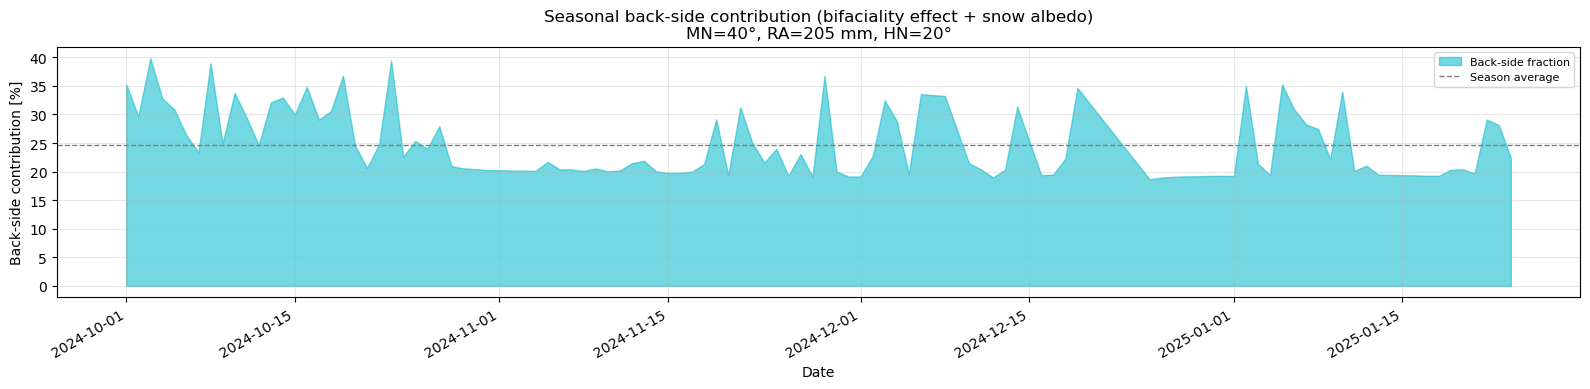

In [30]:
bif_oct_mar = calculate_bifacial_yield(combined, 18, 22, MN=40, RA=205, HN=20)
bif_oct_mar['back_fraction'] = (
    0.9 * bif_oct_mar['yield_Wh_Wp_back'] / bif_oct_mar['yield_bifacial']
).astype(float)

fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(pd.to_datetime(bif_oct_mar['date']),
                bif_oct_mar['back_fraction'] * 100,
                alpha=0.6, color='tab:cyan', label='Back-side fraction')
ax.axhline(bif_oct_mar['back_fraction'].mean() * 100,
           color='grey', lw=1, linestyle='--', label='Season average')
ax.set_ylabel('Back-side contribution [%]')
ax.set_xlabel('Date')
ax.set_title('Seasonal back-side contribution (bifaciality effect + snow albedo)\n'
             'MN=40°, RA=205 mm, HN=20°')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 18. Performance Map – Group Focus HN ≥ 20°

Bifacial yield as a function of row spacing (RA), module tilt (MN), and ground slope (HN) over the full measurement period. A minimum of 5 measurement days per configuration is required for inclusion.

Calculating performance map (this may take a moment)...
Performance map: 24 configurations with sufficient data

⚠  HN=40: 0 configurations with ≥5 days (insufficient measurement coverage)


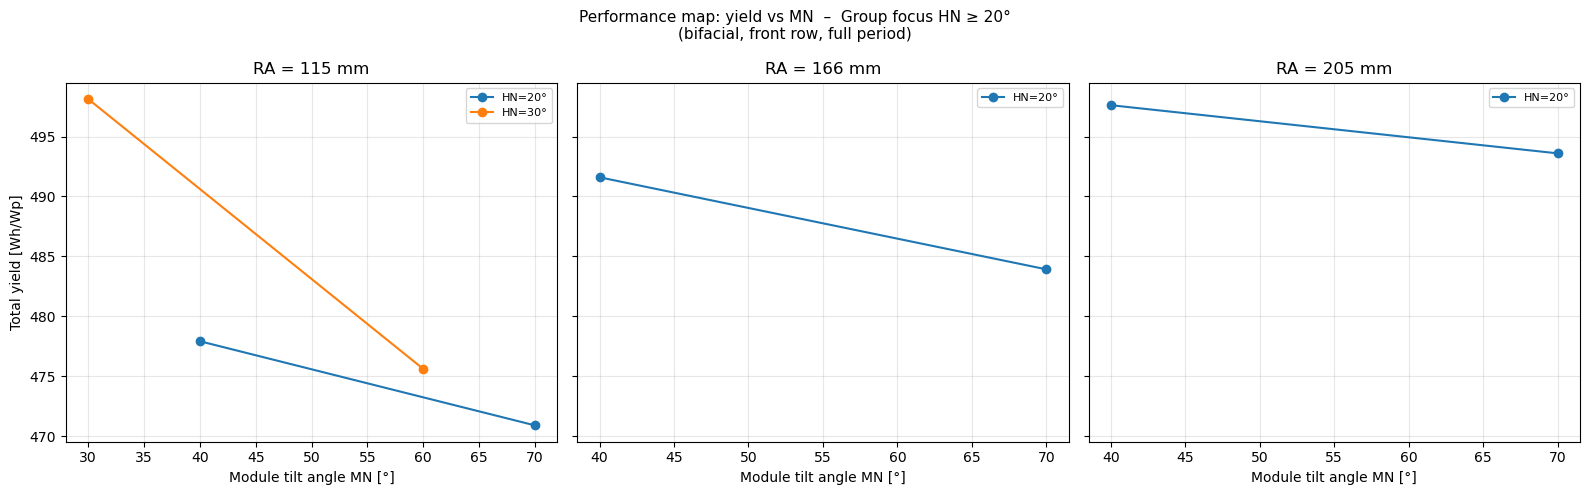

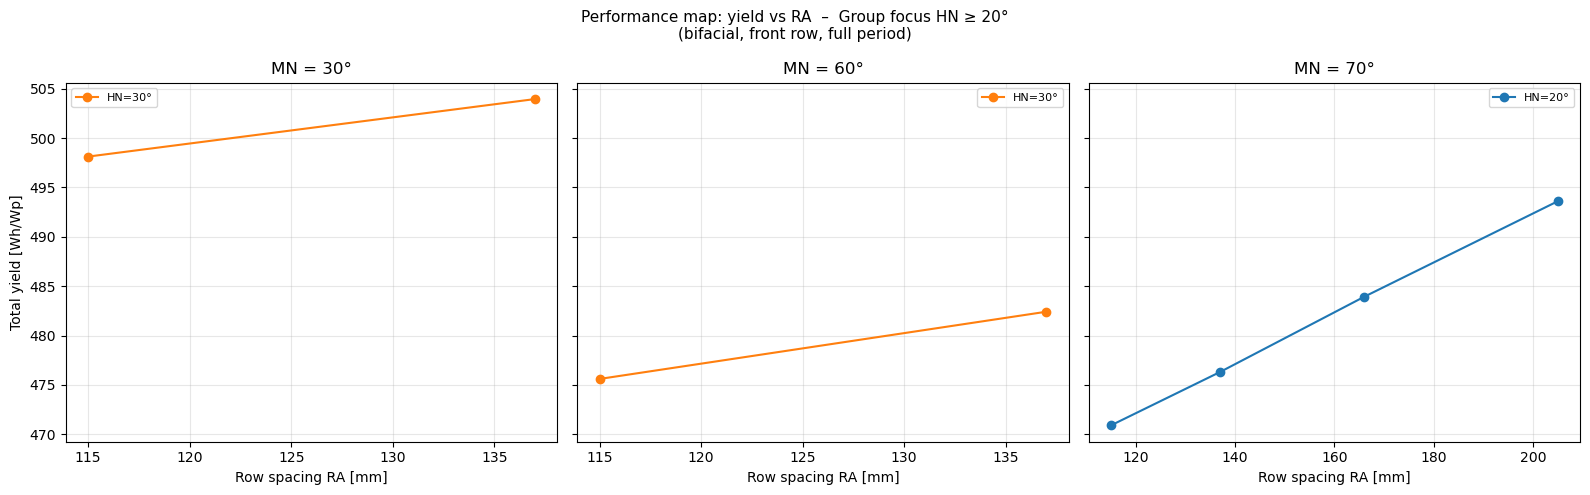


── Available configurations ──────────────────────────────────────────────
HN  MN
20  40    [115, 137, 166, 205]
    70    [115, 137, 166, 205]
30  30              [115, 137]
    60              [115, 137]
HN values with data: [np.int64(20), np.int64(30)]


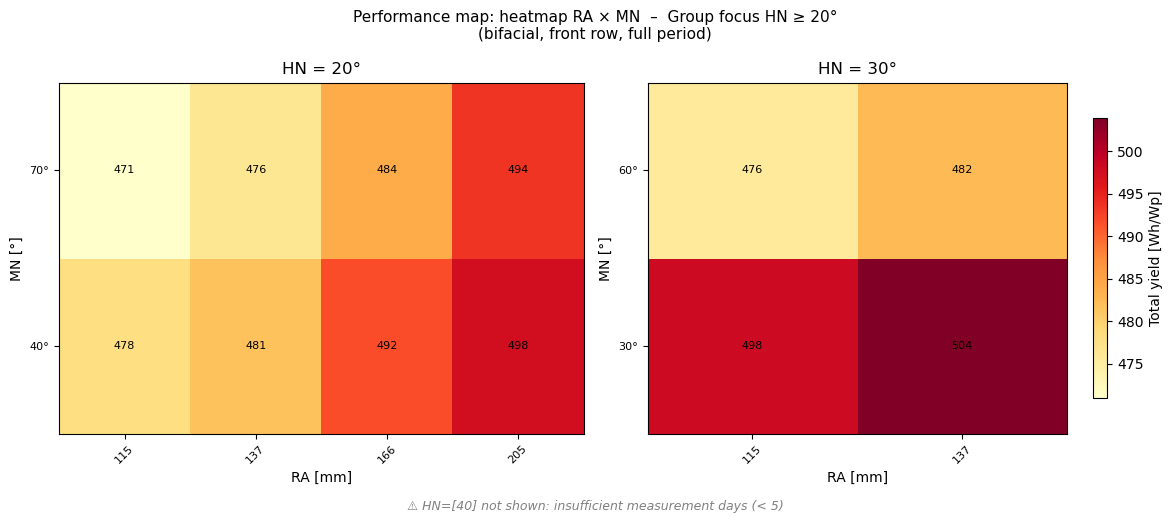


── Best configuration per HN ────────────────────────────────────────────
  HN=20°: MN=40°, RA=205 mm → 497.61 Wh/Wp total, 4.651 Wh/Wp/day (107 days)
  HN=30°: MN=30°, RA=137 mm → 503.95 Wh/Wp total, 4.710 Wh/Wp/day (107 days)


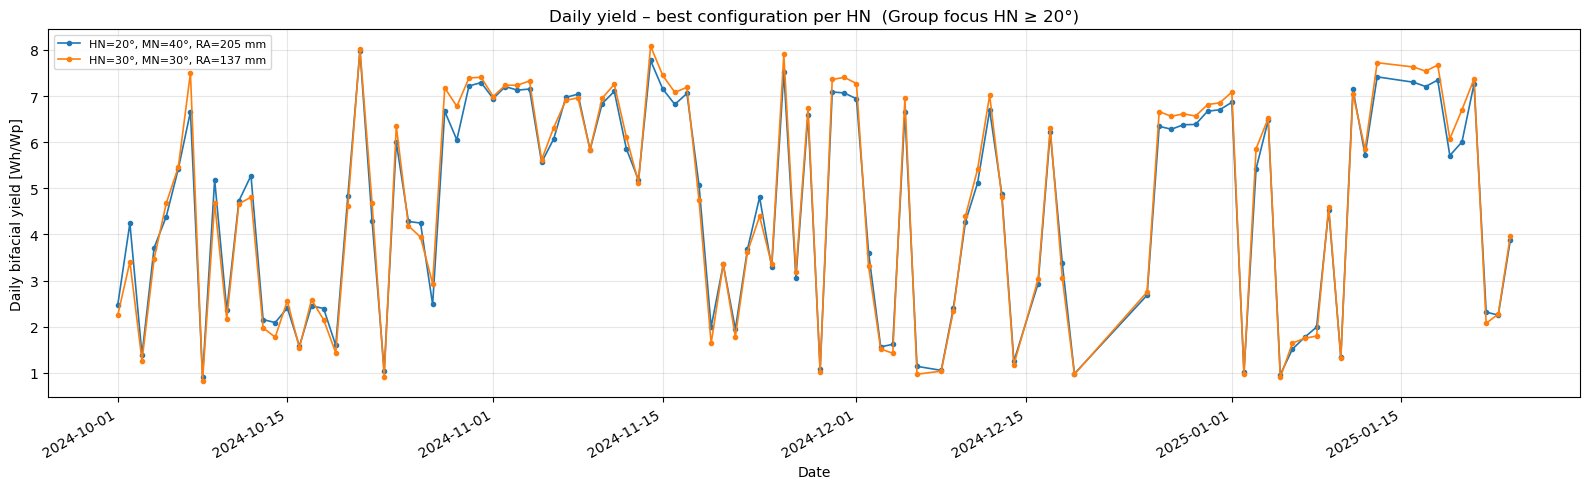


── Performance map summary ───────────────────────────────────────────────
   yield_total                                                                 \
         count     mean      std      min      25%      50%      75%      max   
HN                                                                              
20        16.0  657.411  182.517  470.896  483.312  624.795  833.638  908.742   
30         8.0  674.778  198.948  475.602  494.196  661.567  856.472  901.887   

   yield_per_day                                                   
           count   mean    std    min    25%    50%    75%    max  
HN                                                                 
20          16.0  4.663  0.257  4.347  4.488  4.604  4.819  5.253  
30           8.0  4.774  0.257  4.445  4.619  4.722  4.951  5.213  


In [31]:
HN_FOCUS  = [20, 30, 40]
MN_VALUES = [30, 40, 50, 60, 70, 80, 90]
RA_VALUES = sorted(combined['RA'].dropna().unique())

print("Calculating performance map (this may take a moment)...")

records = []
for hn in HN_FOCUS:
    for mn in MN_VALUES:
        for ra in RA_VALUES:
            for (ch_f, ch_b), row_name in [((18, 22), 'Front row'), ((3, 7), 'Back row')]:
                bif = calculate_bifacial_yield(combined, ch_f, ch_b, MN=mn, RA=ra, HN=hn)
                if len(bif) >= 5:
                    records.append({
                        'HN': hn, 'MN': mn, 'RA': ra,
                        'row':           row_name,
                        'yield_total':   bif['yield_bifacial'].sum(),
                        'yield_per_day': bif['yield_bifacial'].mean(),
                        'n_days':        len(bif),
                    })

perf_map = pd.DataFrame(records)
print(f"Performance map: {len(perf_map)} configurations with sufficient data")

pm_front = perf_map[perf_map['row'] == 'Front row'].copy()

print(f"\n⚠  HN=40: {len(perf_map[perf_map['HN']==40])} configurations with ≥5 days "
      f"(insufficient measurement coverage)")

colors_hn    = {20: 'tab:blue', 30: 'tab:orange', 40: 'tab:red'}
ra_available = sorted(pm_front['RA'].unique())
mn_available = sorted(pm_front['MN'].unique())

# Plot A: yield vs MN for representative RA values
ra_sel = [ra_available[0], ra_available[len(ra_available)//2], ra_available[-1]]

fig, axes = plt.subplots(1, len(ra_sel), figsize=(16, 5), sharey=True)
for ax, ra in zip(axes, ra_sel):
    sub = pm_front[pm_front['RA'] == ra]
    for hn in HN_FOCUS:
        d = sub[sub['HN'] == hn].sort_values('MN')
        if len(d) > 0:
            ax.plot(d['MN'], d['yield_total'],
                    marker='o', lw=1.5, color=colors_hn[hn], label=f'HN={hn}°')
    ax.set_title(f'RA = {ra} mm')
    ax.set_xlabel('Module tilt angle MN [°]')
    ax.grid(True, alpha=0.3)
    if len(sub) > 0:
        ax.legend(fontsize=8)

axes[0].set_ylabel('Total yield [Wh/Wp]')
fig.suptitle('Performance map: yield vs MN  –  Group focus HN ≥ 20°\n'
             '(bifacial, front row, full period)', fontsize=11)
plt.tight_layout()
plt.show()

# Plot B: yield vs RA for representative MN values
mn_sel = [mn_available[0], mn_available[len(mn_available)//2], mn_available[-1]]

fig, axes = plt.subplots(1, len(mn_sel), figsize=(16, 5), sharey=True)
for ax, mn in zip(axes, mn_sel):
    sub = pm_front[pm_front['MN'] == mn]
    for hn in HN_FOCUS:
        d = sub[sub['HN'] == hn].sort_values('RA')
        if len(d) > 0:
            ax.plot(d['RA'], d['yield_total'],
                    marker='o', lw=1.5, color=colors_hn[hn], label=f'HN={hn}°')
    ax.set_title(f'MN = {mn}°')
    ax.set_xlabel('Row spacing RA [mm]')
    ax.grid(True, alpha=0.3)
    if len(sub) > 0:
        ax.legend(fontsize=8)

axes[0].set_ylabel('Total yield [Wh/Wp]')
fig.suptitle('Performance map: yield vs RA  –  Group focus HN ≥ 20°\n'
             '(bifacial, front row, full period)', fontsize=11)
plt.tight_layout()
plt.show()

print("\n── Available configurations ──────────────────────────────────────────────")
print(pm_front.groupby(['HN', 'MN'])['RA'].apply(list).to_string())

# Plot C: heatmap RA × MN per HN
hn_with_data = sorted(pm_front['HN'].unique())
print(f"HN values with data: {hn_with_data}")

fig, axes = plt.subplots(1, len(hn_with_data), figsize=(12, 5))
if len(hn_with_data) == 1:
    axes = [axes]

im = None
for ax, hn in zip(axes, hn_with_data):
    sub   = pm_front[pm_front['HN'] == hn]
    pivot = sub.pivot_table(index='MN', columns='RA', values='yield_total')

    im = ax.imshow(pivot.values, aspect='auto', origin='lower',
                   cmap='YlOrRd',
                   vmin=pm_front['yield_total'].min(),
                   vmax=pm_front['yield_total'].max())

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                        fontsize=8, color='black')

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([str(int(r)) for r in pivot.columns], rotation=45, fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'{int(m)}°' for m in pivot.index], fontsize=8)
    ax.set_xlabel('RA [mm]')
    ax.set_ylabel('MN [°]')
    ax.set_title(f'HN = {hn}°')

if im is not None:
    fig.colorbar(im, ax=axes[-1], label='Total yield [Wh/Wp]', shrink=0.8)

missing_hn = [hn for hn in HN_FOCUS if hn not in hn_with_data]
if missing_hn:
    fig.text(0.5, -0.02,
             f'⚠ HN={missing_hn} not shown: insufficient measurement days (< 5)',
             ha='center', fontsize=9, color='grey', style='italic')

fig.suptitle('Performance map: heatmap RA × MN  –  Group focus HN ≥ 20°\n'
             '(bifacial, front row, full period)', fontsize=11)
plt.tight_layout()
plt.show()

# Plot D: daily bifacial yield for best configuration per HN
print("\n── Best configuration per HN ────────────────────────────────────────────")
best_configs = {}
for hn in HN_FOCUS:
    sub = pm_front[pm_front['HN'] == hn]
    if len(sub) == 0:
        continue
    best = sub.loc[sub['yield_total'].idxmax()]
    best_configs[hn] = best
    print(f"  HN={hn}°: MN={int(best['MN'])}°, RA={int(best['RA'])} mm "
          f"→ {best['yield_total']:.2f} Wh/Wp total, "
          f"{best['yield_per_day']:.3f} Wh/Wp/day ({int(best['n_days'])} days)")

fig, ax = plt.subplots(figsize=(16, 5))
for hn, cfg in best_configs.items():
    bif = calculate_bifacial_yield(
        combined, 18, 22,
        MN=int(cfg['MN']), RA=int(cfg['RA']), HN=hn
    )
    if len(bif) > 0:
        ax.plot(pd.to_datetime(bif['date']), bif['yield_bifacial'],
                marker='o', ms=3, lw=1.2, color=colors_hn[hn],
                label=f'HN={hn}°, MN={int(cfg["MN"])}°, RA={int(cfg["RA"])} mm')

ax.set_ylabel('Daily bifacial yield [Wh/Wp]')
ax.set_xlabel('Date')
ax.set_title('Daily yield – best configuration per HN  (Group focus HN ≥ 20°)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print("\n── Performance map summary ───────────────────────────────────────────────")
print(perf_map.groupby('HN')[['yield_total', 'yield_per_day']].describe().round(3))

## 19. In-Plane Irradiance (POA) via pvlib

POA (Plane-of-Array) irradiance is the total irradiance incident on the module surface, accounting for module tilt and azimuth. It is used as a feature in the regression model.

DHI is not directly measured and is estimated as:  `DHI = max(GHI − DNI × cos(zenith), 0)`

The site is south-facing (azimuth = 180°) and surface tilt equals MN.

In [33]:
def calculate_poa_irradiance(mn_deg, hn_deg, env_df, solpos_df_full):
    """
    Calculate daily total POA irradiance [Wh/m²] for a given module tilt (MN).
    Uses pvlib's get_total_irradiance() with Perez transposition model.
    """
    df  = env_df.copy()
    sol = solpos_df_full[['zenith', 'elevation', 'azimuth']].copy()
    sol = sol[sol['elevation'] > 0]

    df = df.merge(sol, left_on='Timestamp', right_index=True, how='inner')
    df = df[df['elevation'] > 0].copy()

    cos_zen   = np.cos(np.radians(df['zenith']))
    df['DHI'] = np.maximum(df['GHI'] - df['DNI'] * cos_zen, 0)

    poa = pvlib.irradiance.get_total_irradiance(
        surface_tilt    = mn_deg,
        surface_azimuth = 180,
        solar_zenith    = df['zenith'],
        solar_azimuth   = df['azimuth'],
        dni             = df['DNI'],
        ghi             = df['GHI'],
        dhi             = df['DHI'],
    )
    df['POA'] = poa['poa_global']
    df['date'] = df['Timestamp'].dt.date
    return df.groupby('date')['POA'].sum() / 3600


# IMPORTANT: assign Timestamp series directly (not .values) to preserve timezone
print("Calculating solar position for environmental timestamps...")
solpos_env       = location.get_solarposition(env_data_full['Timestamp'])
solpos_env.index = env_data_full['Timestamp']

print("Calculating POA irradiance for measured MN values...")
poa_by_mn = {}
for mn in [30, 40, 60, 70]:
    poa_by_mn[mn] = calculate_poa_irradiance(mn, 0, env_data_full, solpos_env)
    print(f"  MN={mn}°: {poa_by_mn[mn].sum():.0f} Wh/m² total period")

Calculating solar position for environmental timestamps...
Calculating POA irradiance for measured MN values...
  MN=30°: 61368 Wh/m² total period
  MN=40°: 65050 Wh/m² total period
  MN=60°: 67799 Wh/m² total period
  MN=70°: 66782 Wh/m² total period


## 20. Regression Model – Aggregated Yields

**Goal:** predict yield for unmeasured configurations (e.g. HN=40, other RA/MN combinations).  
**Training data:** 12 aggregated total yields (one per measured configuration).

> ⚠ Only 12 training points — cross-validation is not meaningful.  
> This model serves as a methodological illustration only.

In [34]:
poa_total_by_mn      = {mn: v.sum() for mn, v in poa_by_mn.items()}
pm_model             = pm_front.copy()
pm_model['POA_total'] = pm_model['MN'].map(poa_total_by_mn)

feature_cols = ['HN', 'MN', 'RA', 'POA_total']
X = pm_model[feature_cols].values
y = pm_model['yield_total'].values

print(f"Training data: {len(X)} configurations")

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = GradientBoostingRegressor(
    n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42
)
model.fit(X_scaled, y)

print("\nFeature importance (12 training points):")
for feat, imp in zip(feature_cols, model.feature_importances_):
    print(f"  {feat}: {imp:.3f}")

mn_poa_known = np.array(sorted(poa_total_by_mn.keys()))
poa_known    = np.array([poa_total_by_mn[mn] for mn in mn_poa_known])
RA_ALL       = sorted(combined['RA'].dropna().unique())

pred_records = []
for hn in [20, 30, 40]:
    for mn in [30, 40, 50, 60, 70, 80, 90]:
        poa_mn = float(np.interp(mn, mn_poa_known, poa_known))
        for ra in RA_ALL:
            feat      = scaler.transform([[hn, mn, ra, poa_mn]])
            y_pred    = model.predict(feat)[0]
            measured  = pm_front[
                (pm_front['HN'] == hn) &
                (pm_front['MN'] == mn) &
                (pm_front['RA'] == ra)
            ]
            y_measured = measured['yield_total'].values[0] if len(measured) > 0 else np.nan
            pred_records.append({
                'HN': hn, 'MN': mn, 'RA': ra,
                'POA_total': poa_mn,
                'yield_predicted': y_pred,
                'yield_measured':  y_measured,
                'has_data':        not np.isnan(y_measured),
            })

pred_df = pd.DataFrame(pred_records)
print(f"\nPredictions: {len(pred_df)} configurations total")
print(f"  measured:   {pred_df['has_data'].sum()}")
print(f"  predicted:  {(~pred_df['has_data']).sum()}")

Training data: 12 configurations

Feature importance (12 training points):
  HN: 0.016
  MN: 0.306
  RA: 0.487
  POA_total: 0.192

Predictions: 210 configurations total
  measured:   12
  predicted:  198


## 21. Improved Model – Daily Yields as Training Data

Instead of 12 aggregated totals, ~1260 daily yield values are used as training data. This enables meaningful 5-fold cross-validation (R² = 0.94).

> ⚠ **Limitation:** POA_day accounts for 98% of feature importance.  
> The model has learned the **weather effect** (more sun = more yield), not the  
> **configuration effect** (RA, MN, HN differences). Day-to-day weather variation  
> dominates over configuration differences in this dataset.  
> The model is suitable for interpolation within measured configurations,  
> but **not** for robust extrapolation to unmeasured ones.

In [35]:
daily_records = []
for (ch_f, ch_b), row_name in [((18, 22), 'Front row'), ((3, 7), 'Back row')]:
    for hn, mn, ra in [
        (20, 40, 115), (20, 40, 137), (20, 40, 166), (20, 40, 205),
        (20, 70, 115), (20, 70, 137), (20, 70, 166), (20, 70, 205),
        (30, 30, 115), (30, 30, 137),
        (30, 60, 115), (30, 60, 137),
    ]:
        bif = calculate_bifacial_yield(combined, ch_f, ch_b, MN=mn, RA=ra, HN=hn)
        if len(bif) == 0:
            continue

        poa_mn_daily = poa_by_mn.get(mn)
        if poa_mn_daily is None:
            continue

        for _, row in bif.iterrows():
            date    = row['date']
            poa_day = poa_mn_daily.get(date, np.nan)
            if np.isnan(poa_day) or poa_day <= 0:
                continue
            daily_records.append({
                'HN': hn, 'MN': mn, 'RA': ra,
                'row':     row_name,
                'date':    date,
                'POA_day': poa_day,
                'yield_day': row['yield_bifacial'],
            })

daily_df       = pd.DataFrame(daily_records)
daily_df_front = daily_df[daily_df['row'] == 'Front row'].copy()

print(f"Daily training data: {len(daily_df_front)} data points "
      f"(vs. 12 aggregated values in Section 15)")

feature_cols_daily = ['HN', 'MN', 'RA', 'POA_day']
X_daily = daily_df_front[feature_cols_daily].values
y_daily = daily_df_front['yield_day'].values

scaler_daily   = StandardScaler()
X_daily_scaled = scaler_daily.fit_transform(X_daily)

model_daily = GradientBoostingRegressor(
    n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42
)
model_daily.fit(X_daily_scaled, y_daily)

cv_scores_daily = cross_val_score(
    model_daily, X_daily_scaled, y_daily,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2'
)
print(f"\nCross-validation R² (5-fold): "
      f"{cv_scores_daily.mean():.3f} ± {cv_scores_daily.std():.3f}")

print("\nFeature importance (daily data):")
for feat, imp in zip(feature_cols_daily, model_daily.feature_importances_):
    print(f"  {feat}: {imp:.3f}")

print("\n⚠ POA_day dominates with 98% feature importance.")
print("  Model captures weather effect, not configuration effect.")
print("  Suitable for interpolation within measured configurations only.")

Daily training data: 1260 data points (vs. 12 aggregated values in Section 15)

Cross-validation R² (5-fold): 0.942 ± 0.012

Feature importance (daily data):
  HN: 0.001
  MN: 0.016
  RA: 0.001
  POA_day: 0.982

⚠ POA_day dominates with 98% feature importance.
  Model captures weather effect, not configuration effect.
  Suitable for interpolation within measured configurations only.


## 22. Results & Interpretation – Group Focus HN ≥ 20°

**1. Optimal module tilt at steep ground slopes**  
At HN=20°, MN=40° is optimal; at HN=30°, MN=30° is optimal. This is physically consistent: the ground slope itself already tilts the array toward the sun, a high additional module tilt would overcorrect and reduce yield.

**2. Row spacing (RA)**  
Larger row spacing consistently increases yield due to reduced inter-row shading. The effect is visible but modest within the measured RA range of 115–205 mm.

**3. Data coverage**  
For HN ≥ 20°, only a limited number of configurations were measured:
- HN=20°: MN=40° and MN=70°, RA=115–205 mm
- HN=30°: MN=30° and MN=60°, RA=115–137 mm
- HN=40°: insufficient measurement days (< 5) for statistical analysis

**4. Back-side contribution (bifaciality)**  
The back side contributes on average ~25% of total bifacial yield, with peaks up to 40% on days with fresh snow cover.

**5. Regression model**  
The daily-yield model (R²=0.94) shows that the weather effect (POA_day = 98% feature importance) dominates configuration differences. Robust extrapolation to unmeasured configurations would require a broader set of measured configurations.

**6. Note on HN=40°**  
HN=40° had fewer than 5 measurement days for all configurations and therefore cannot be evaluated from measurement data alone. This is likely because the Mini-PVA spent less time at this extreme ground slope. For HN=40°, only the regression model provides estimates. These should be treated with caution given the model's limited training data and the dominance of the weather effect over the configuration effect.

**7. Seasonal patterns**  
The daily yield calendar (Plot 6, Section 16) clearly shows the seasonal decline from October toward December and the recovery in March, consistent with the changing sun elevation at this alpine site. The three missing data periods (December 7, December 20–24, January 14–15) are also visible as gaps. The seasonal back-side contribution plot (Section 17) confirms that snow albedo events drive the back-side fraction above 30–40% on individual days, particularly in winter months.